In [1]:
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from natsort import natsorted
from os import listdir
from os.path import isfile, join
import torch
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from dataloader_wrapper import DataloaderWrapper
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger
from torch import nn
from torchvision.transforms import v2
from sklearn import metrics
import json
import sys
import gc

#my imports
sys.path.append("./")
from my_code.utils import run_metrics
from my_code.model import MyModel
from my_code.dataset import create_dataloader

import os
os.environ["OMP_NUM_THREADS"] = "1" #https://github.com/pytorch/pytorch/issues/15808 + https://stackoverflow.com/questions/30791550/limit-number-of-threads-in-numpy
os.environ["MKL_NUM_THREADS"] = "1"

C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [ ]:
relative_path_to_data = None #Must set

train_sets = []
train_sets = [f.name for f in os.scandir(relative_path_to_data) if f.is_dir() and "checkpoint" not in f.name]

test_sets = [
    "1286_2921_13",
    "1330_3107_13",
    "2196_3885_13",
    "3830_3914_13",
    "4523_4210_13",
    "4553_3325_13",
    "5195_3388_13",
    "5754_3601_13",
    "5912_3937_13",
    "6752_3104_13"
]

val_sets = [
    "1973_3709_13",
    "2569_4513_13",
    "2789_4694_13",
    "4062_3943_13",
    "4666_2369_13",
    "5830_3834_13",
    "6353_3661_13",
    "6678_3579_13",
    "6761_3129_13",
    "7517_4908_13"
]

USING DEFAULT TRAIN SET


In [ ]:

with open("./default_train_set_normalization_data.json", 'r') as file:
    normalization_data = json.load(file)  # Load JSON data into a Python dictionary or list

my_train_means = np.array([float(normalization_data["means"]["R"]), float(normalization_data["means"]["G"]), float(normalization_data["means"]["B"]), float(normalization_data["means"]["infra"])])
my_train_stds = np.array([float(normalization_data["stds"]["R"]), float(normalization_data["stds"]["G"]), float(normalization_data["stds"]["B"]), float(normalization_data["stds"]["infra"])])

In [4]:
n_classes = 7 #CONST
in_channels = None
RGB_or_RGB_plus_near_INFRARED = "rgb_plus_infrared" #"rgb_plus_infrared" #also with infrared: "rgb_plus_infrared"
if RGB_or_RGB_plus_near_INFRARED not in ["only_rgb", "rgb_plus_infrared"]:
    raise Exception("Incorrect value for parameter RGB_or_RGB_plus_near_INFRARED")

if RGB_or_RGB_plus_near_INFRARED == "only_rgb":
    in_channels = 3
elif RGB_or_RGB_plus_near_INFRARED == "rgb_plus_infrared":
    in_channels = 4
    
num_workers = 0

In [ ]:
model_arch = "GASSL-GEO" 
#model options:
#1. "Unet": No need to run, but I did anyway (with batch size = 4)
#2. GASSL: (all with batch = 4, patience = 3)
##- "GASSL-basic"
##- "GASSL-TP"
##- "GASSL-GEO"
##- "GASSL-GEO+TP"
#3. SeCo: (all with batch = 4, patience = 3)
##- "SeCo-100K-ResNet-18"
##- "SeCo-100K-ResNet-50"
##- "SeCo-1M-ResNet-18"
##- "SeCo-1M-ResNet-50"
#4. SatMAE: (some with batch size = 1, others = 2)
##- "SatMAE_fMoW_Non_Temporal_ViT-Large"
##- "SatMAE_fMoW_Temporal_ViT-Large"
##- "SatMAE_fMoW_MultiSpectral_ViT-Base"
##- "SatMAE_fMoW_MultiSpectral_ViT-Large"
#5. TOV: (all with batch = 2, patience = 3)

loss_function = "CrossEntropyLoss" #or "CrossEntropyLoss"
n_epochs = 200
log_every_n_steps = 1
patience = 3
n_runs = 7
show_images = True
selected_set_to_evaluate = "test"
batch_size = 4 #set to 2 for ViTs
use_my_dataset_means_and_stds = True
is_temporal = False
if model_arch in ["SatMAE_fMoW_Temporal_ViT-Large"]:
    is_temporal = True
    in_channels = 12 

In [ ]:
train_means = my_train_means
train_stds = my_train_stds

print("Using means and stds:", train_means, train_means.shape, "/", train_stds, train_stds.shape)

Using means and stds: [1083.07    942.2352  687.3373 2625.4485] (4,) / [420.83426 307.49545 270.2855  603.5478 ] (4,)


In [8]:
print("Working on TRAIN dataset")
#train_dataloader = create_dataloader(train_sets, "train", batch_size=16, shuffle=True, num_workers=num_workers)
train_dataloader = create_dataloader(train_sets, "train", n_classes, RGB_or_RGB_plus_near_INFRARED, verbose=False, batch_size=batch_size, shuffle=True, num_workers=num_workers, relative_path_to_data=relative_path_to_data, keep_interval = "monthly", temporal=is_temporal)

print("Working on VAL dataset")
#val_dataloader = create_dataloader(val_sets, "val", batch_size=16, shuffle=False, num_workers=num_workers)
val_dataloader = create_dataloader(val_sets, "val", n_classes, RGB_or_RGB_plus_near_INFRARED, verbose=False, batch_size=batch_size, shuffle=False, num_workers=num_workers, relative_path_to_data=relative_path_to_data, keep_interval = "monthly", temporal=is_temporal)

T_MAX = n_epochs * len(train_dataloader)

Working on TRAIN dataset
Working on  1311_3077_13 (# 1 / 55 )
Working on  1417_3281_13 (# 2 / 55 )
Working on  1487_3335_13 (# 3 / 55 )
Working on  1700_3100_13 (# 4 / 55 )
Working on  2006_3280_13 (# 5 / 55 )
Working on  2029_3764_13 (# 6 / 55 )
Working on  2065_3647_13 (# 7 / 55 )
Working on  2235_3403_13 (# 8 / 55 )
Working on  2415_3082_13 (# 9 / 55 )
Working on  2459_4406_13 (# 10 / 55 )
Working on  2470_5030_13 (# 11 / 55 )
Working on  2528_4620_13 (# 12 / 55 )
Working on  2624_4314_13 (# 13 / 55 )
Working on  2697_3715_13 (# 14 / 55 )
Working on  2832_4366_13 (# 15 / 55 )
Working on  2850_4139_13 (# 16 / 55 )
Working on  3002_4273_13 (# 17 / 55 )
Working on  3998_3016_13 (# 18 / 55 )
Working on  4127_2991_13 (# 19 / 55 )
Working on  4169_3944_13 (# 20 / 55 )
Working on  4223_3246_13 (# 21 / 55 )
Working on  4240_3972_13 (# 22 / 55 )
Working on  4254_2915_13 (# 23 / 55 )
Working on  4397_4302_13 (# 24 / 55 )
Working on  4421_3800_13 (# 25 / 55 )
Working on  4426_3835_13 (# 26 / 5

## Run N_RUNS of training and evaluation

=> loading checkpoint './methods/GASSL/moco_fmow/weights/moco_geo.pth.tar'
=> loaded MoCo‐pretrained weights from './methods/GASSL/moco_fmow/weights/moco_geo.pth.tar'


Using 16bit None Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


318 tensor(s) updated after loading weights...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                    | Type                 | Params
-----------------------------------------------------------------
0 | scaling_transform       | Compose              | 0     
1 | encoder                 | MoCoResNet50Backbone | 23.5 M
2 | decoder                 | UPerNetDecoder       | 13.8 M
3 | segmentation_head       | SegmentationHead     | 1.8 K 
4 | loss_fn                 | SoftCrossEntropyLoss | 0     
5 | augmentation_transform  | Compose              | 0     
6 | normalization_transform | Compose              | 0     
-----------------------------------------------------------------
37.3 M    Trainable params
0         Non-trainable params
37.3 M    Total params
74.579    Total estimated model params size (MB)
C:\Users\Domen\AppData\Roaming\Python\Python310\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may b

Training: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Epoch 2, global step 990: 'valid_loss' was not in top 1


Validation: 0it [00:00, ?it/s]

Monitored metric valid_loss did not improve in the last 3 records. Best score: 0.869. Signaling Trainer to stop.
Epoch 3, global step 1320: 'valid_loss' was not in top 1


Run # 1
TEST set:
Working on  1286_2921_13 (# 1 / 1 )
Number of all paths: 24


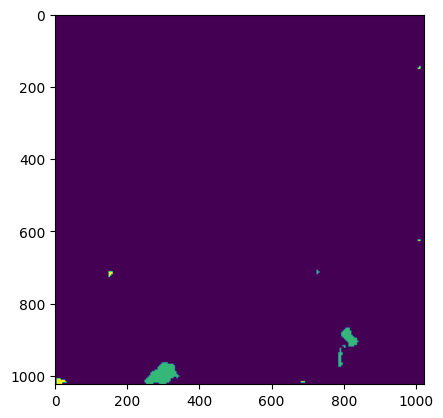

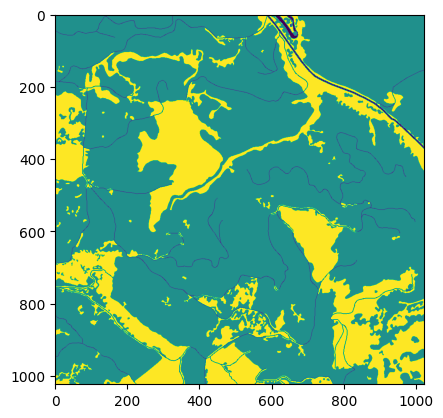

Working on  1330_3107_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


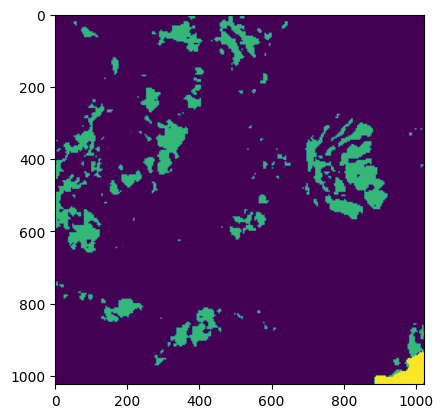

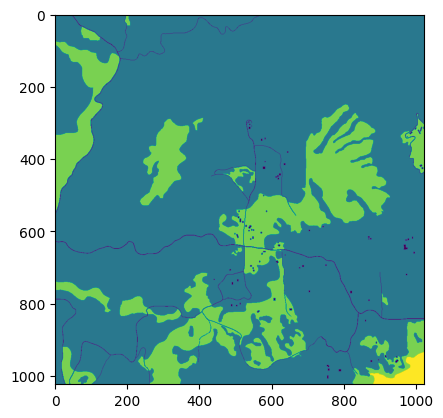

Working on  2196_3885_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


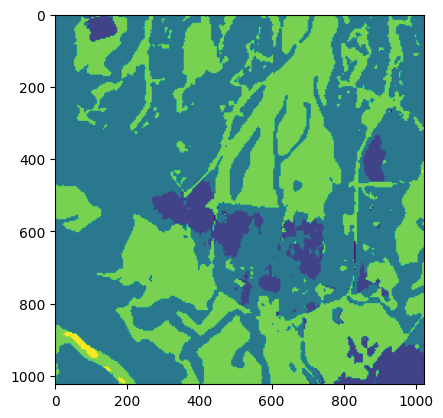

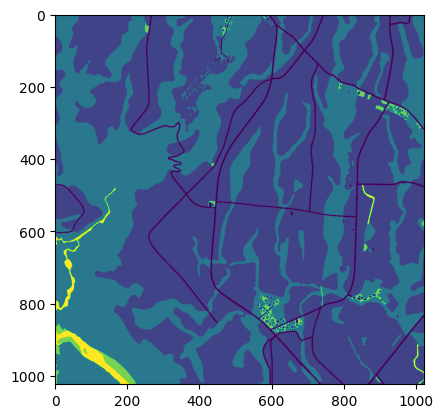

Working on  3830_3914_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


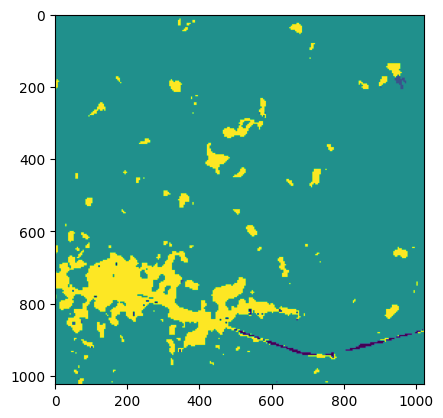

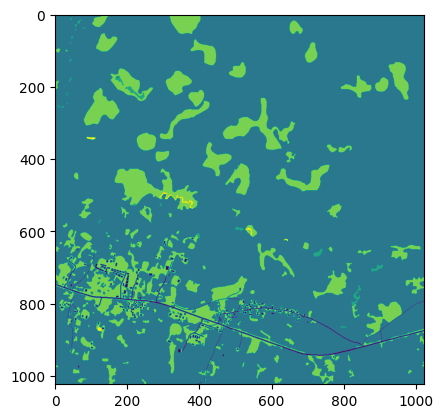

Working on  4523_4210_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


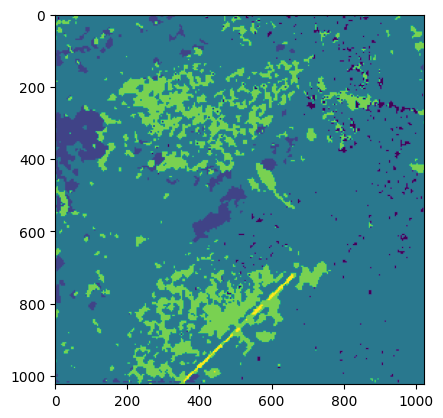

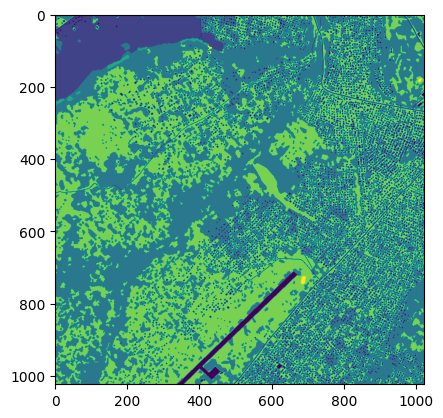

Working on  4553_3325_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


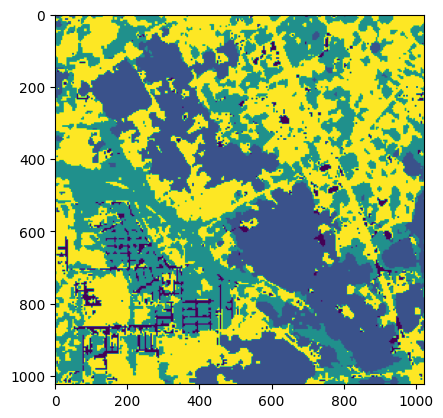

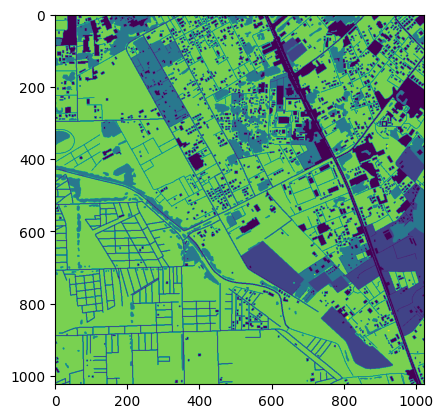

Working on  5195_3388_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


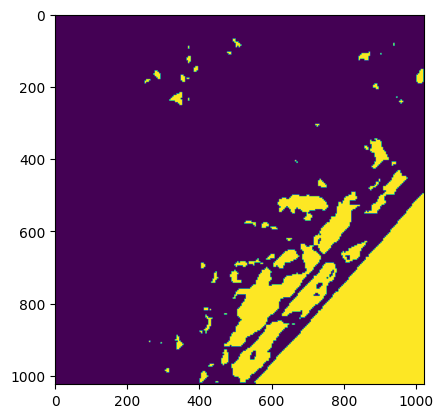

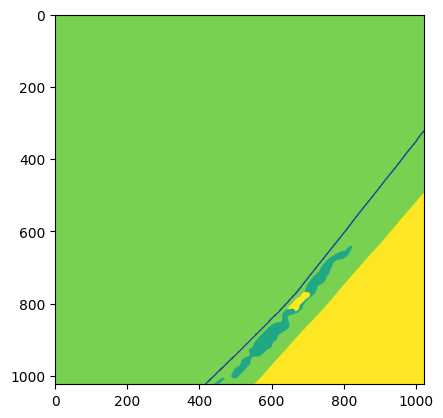

Working on  5754_3601_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


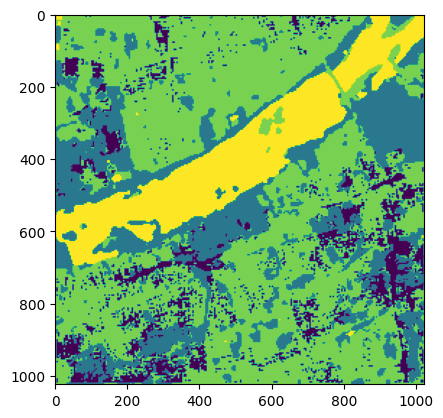

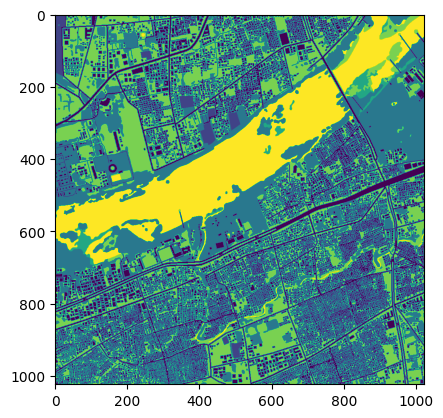

Working on  5912_3937_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


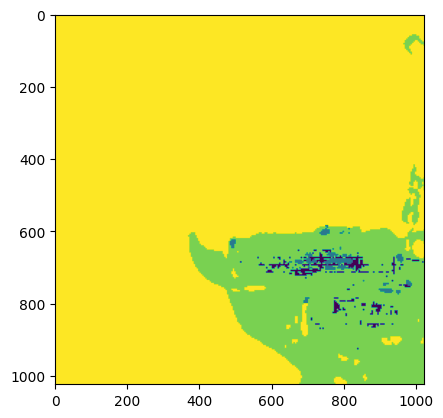

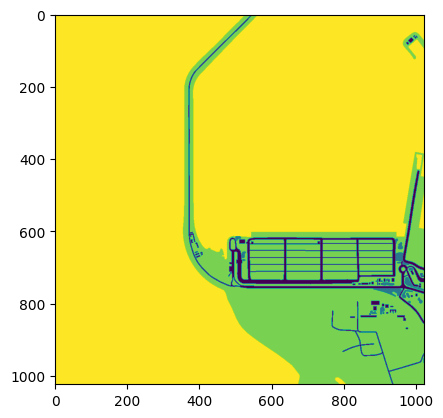

Working on  6752_3104_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


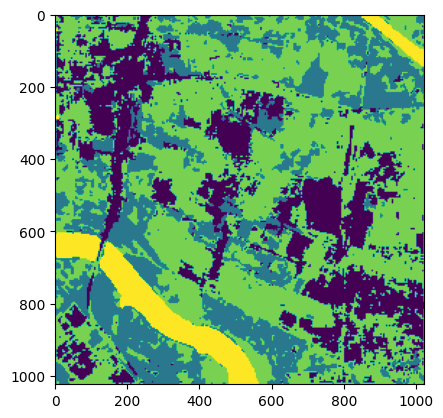

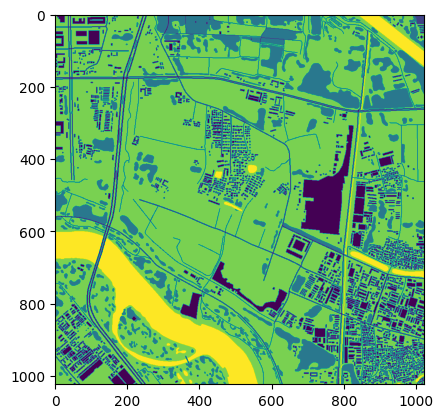

Individual subset mIOUs: [0.41099249277857636, 0.48824703650450985, 0.22894599933962345, 0.23034334253715075, 0.116139895716294, 0.20723944835337096, 0.27895767771994234, 0.3306666607039086, 0.43252042834453297, 0.3602363607568213]
Individual subset weighted F1s: [0.8446318849976376, 0.7738767173505493, 0.5955479033743332, 0.8046511440497673, 0.3971239762034846, 0.4851338725673824, 0.7514178535090573, 0.5416261268224378, 0.8920602126260863, 0.6777702674877301]
Dataset mIOU: 0.3752966200200505
Dataset weighted F1: 0.6656770559778645
Dataset weighted F1 - corrected: 0.6655985665651524
Dataset macro F1: 0.48592275143725877
Dataset macro F1 - corrected: 0.4858872723734353
____
=> loading checkpoint './methods/GASSL/moco_fmow/weights/moco_geo.pth.tar'
=> loaded MoCo‐pretrained weights from './methods/GASSL/moco_fmow/weights/moco_geo.pth.tar'


Using 16bit None Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


318 tensor(s) updated after loading weights...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                    | Type                 | Params
-----------------------------------------------------------------
0 | scaling_transform       | Compose              | 0     
1 | encoder                 | MoCoResNet50Backbone | 23.5 M
2 | decoder                 | UPerNetDecoder       | 13.8 M
3 | segmentation_head       | SegmentationHead     | 1.8 K 
4 | loss_fn                 | SoftCrossEntropyLoss | 0     
5 | augmentation_transform  | Compose              | 0     
6 | normalization_transform | Compose              | 0     
-----------------------------------------------------------------
37.3 M    Trainable params
0         Non-trainable params
37.3 M    Total params
74.579    Total estimated model params size (MB)
C:\Users\Domen\AppData\Roaming\Python\Python310\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may b

Training: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Epoch 5, global step 1980: 'valid_loss' was not in top 1


Validation: 0it [00:00, ?it/s]

Monitored metric valid_loss did not improve in the last 3 records. Best score: 0.911. Signaling Trainer to stop.
Epoch 6, global step 2310: 'valid_loss' was not in top 1


Run # 2
TEST set:
Working on  1286_2921_13 (# 1 / 1 )
Number of all paths: 24


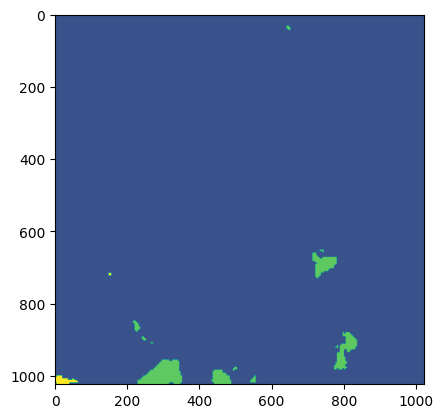

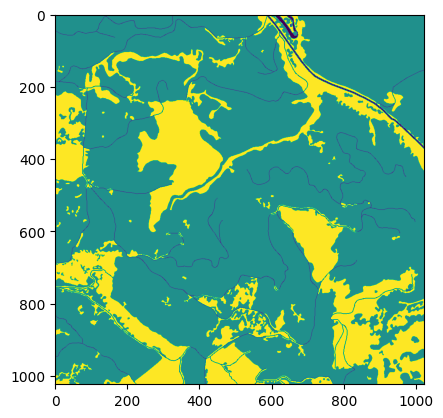

Working on  1330_3107_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


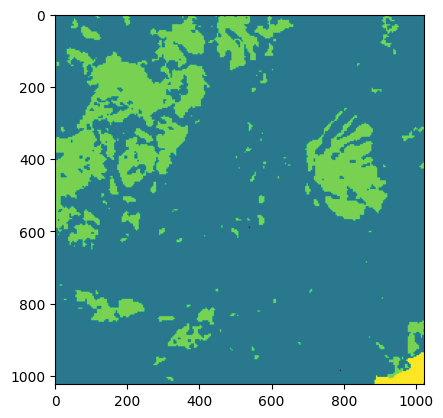

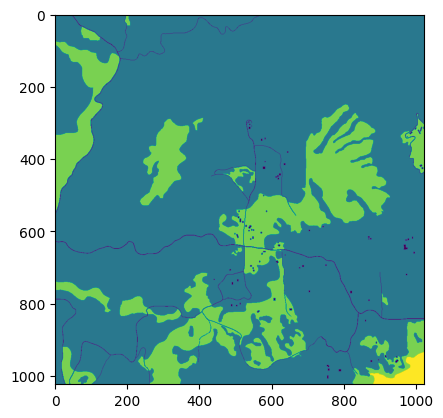

Working on  2196_3885_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


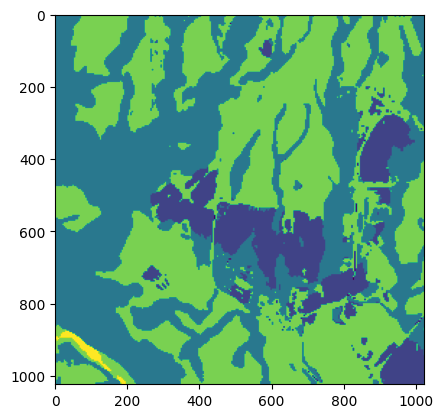

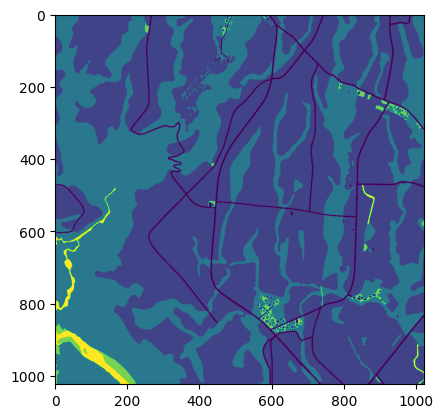

Working on  3830_3914_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


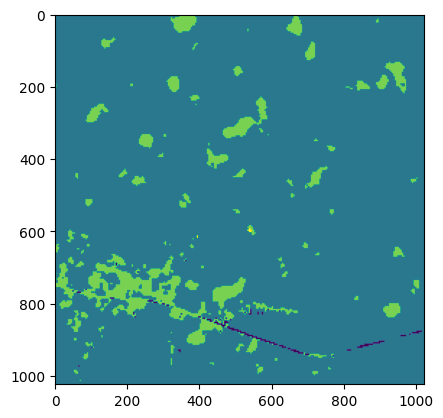

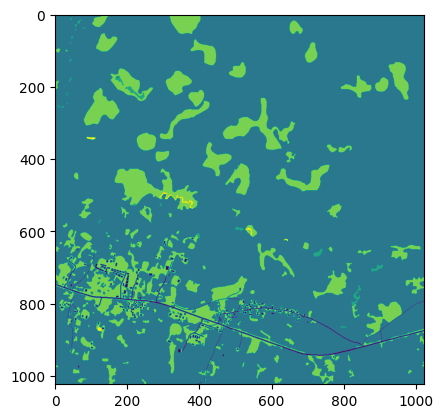

Working on  4523_4210_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


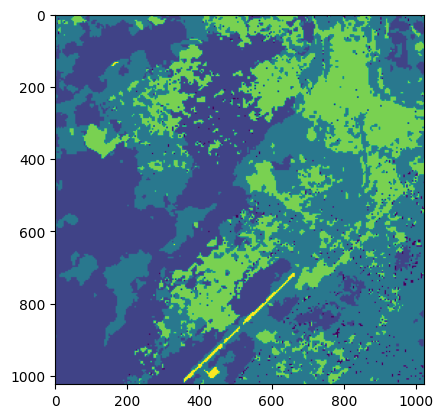

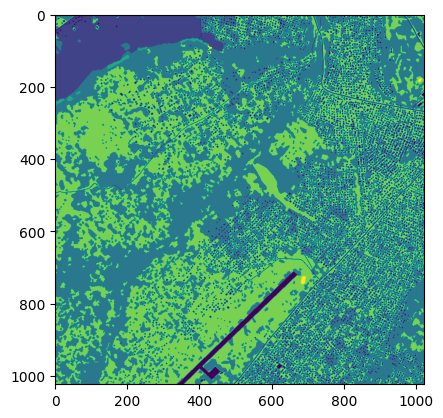

Working on  4553_3325_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


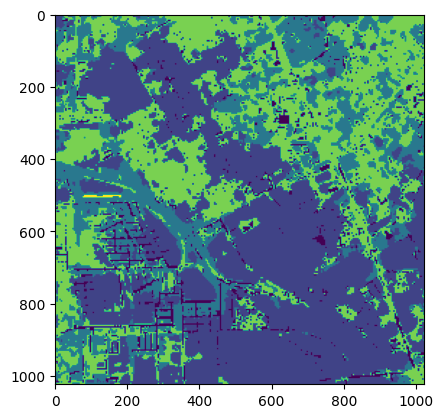

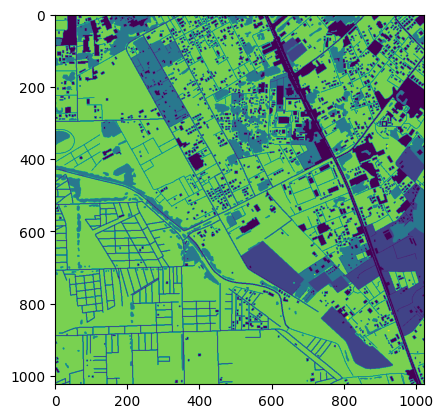

Working on  5195_3388_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


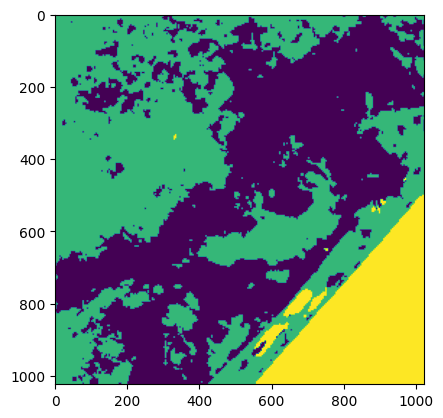

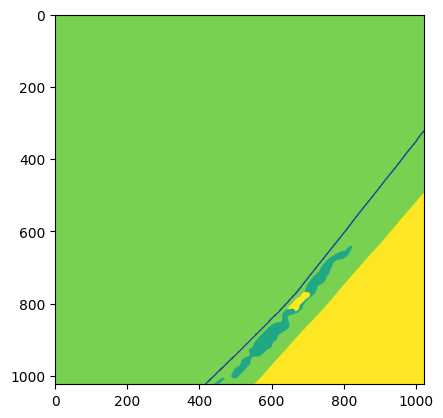

Working on  5754_3601_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


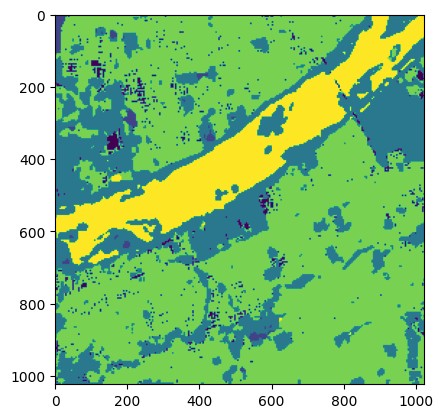

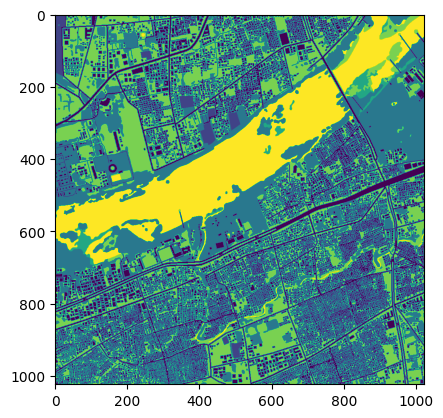

Working on  5912_3937_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


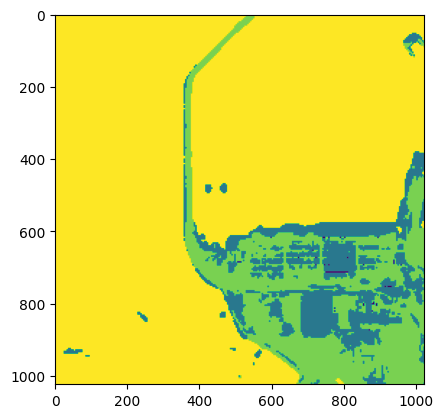

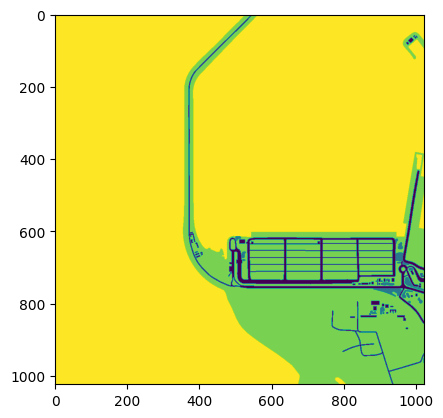

Working on  6752_3104_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


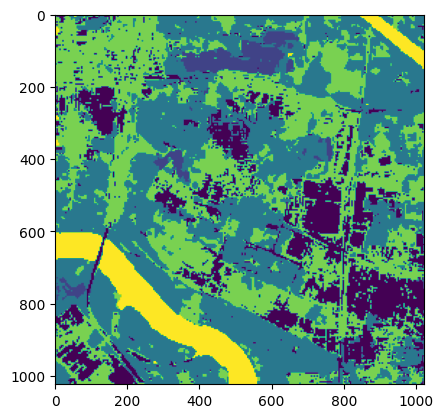

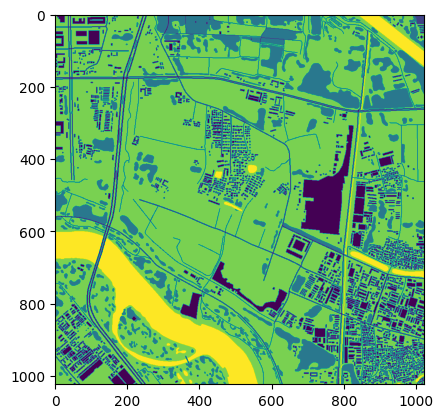

Individual subset mIOUs: [0.4363942730220673, 0.46963478973481176, 0.27847526653363947, 0.2532253268801, 0.11836573960661113, 0.20364223559628508, 0.31251106274935025, 0.3319675950897219, 0.41988524544307326, 0.3489306139343508]
Individual subset weighted F1s: [0.8600472790455885, 0.7253348325946342, 0.6680668112111984, 0.8348590478977038, 0.3851134095930537, 0.45485819123597665, 0.7270656240278671, 0.5075278123540686, 0.8928571192635171, 0.6413712717365798]
Dataset mIOU: 0.3793012477163722
Dataset weighted F1: 0.648730454563436
Dataset weighted F1 - corrected: 0.6487130357197998
Dataset macro F1: 0.4860454215853291
Dataset macro F1 - corrected: 0.4860389698656838
____
=> loading checkpoint './methods/GASSL/moco_fmow/weights/moco_geo.pth.tar'
=> loaded MoCo‐pretrained weights from './methods/GASSL/moco_fmow/weights/moco_geo.pth.tar'
318 tensor(s) updated after loading weights...


Using 16bit None Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                    | Type                 | Params
-----------------------------------------------------------------
0 | scaling_transform       | Compose              | 0     
1 | encoder                 | MoCoResNet50Backbone | 23.5 M
2 | decoder                 | UPerNetDecoder       | 13.8 M
3 | segmentation_head       | SegmentationHead     | 1.8 K 
4 | loss_fn               

Training: 0it [00:00, ?it/s]

C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Epoch 3, global step 1320: 'valid_loss' was not in top 1


Validation: 0it [00:00, ?it/s]

Monitored metric valid_loss did not improve in the last 3 records. Best score: 0.874. Signaling Trainer to stop.
Epoch 4, global step 1650: 'valid_loss' was not in top 1


Run # 3
TEST set:
Working on  1286_2921_13 (# 1 / 1 )
Number of all paths: 24


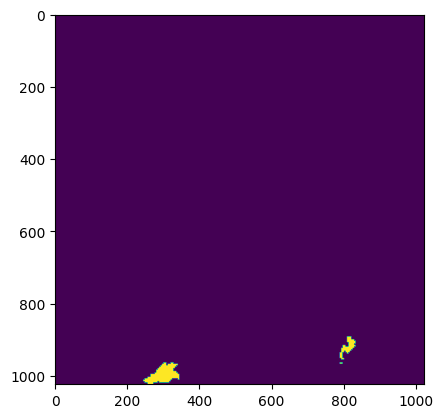

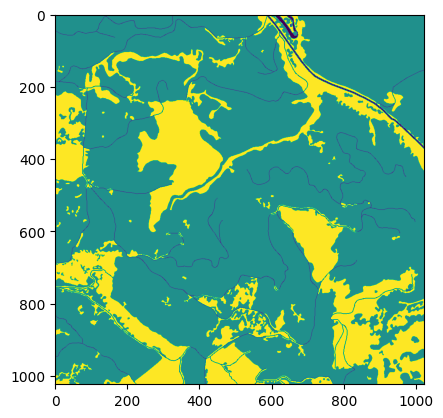

Working on  1330_3107_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


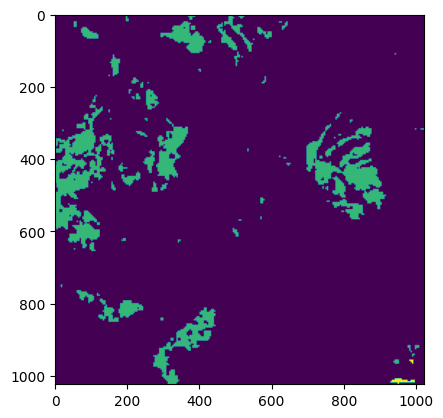

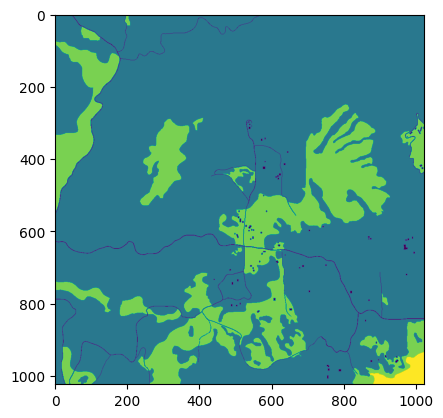

Working on  2196_3885_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


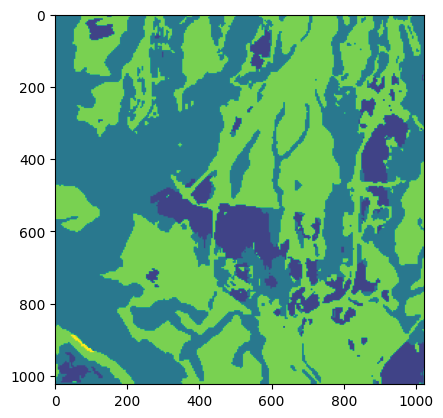

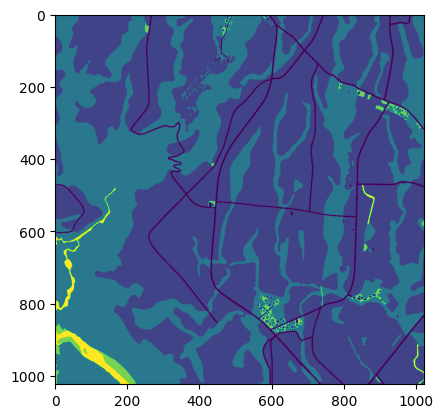

Working on  3830_3914_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


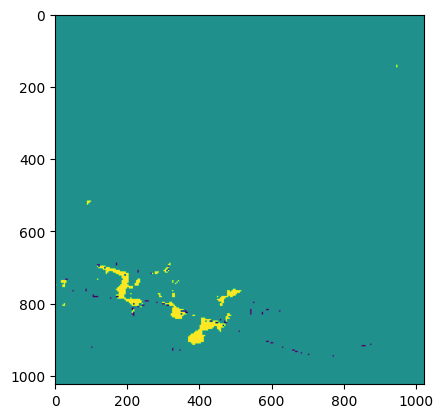

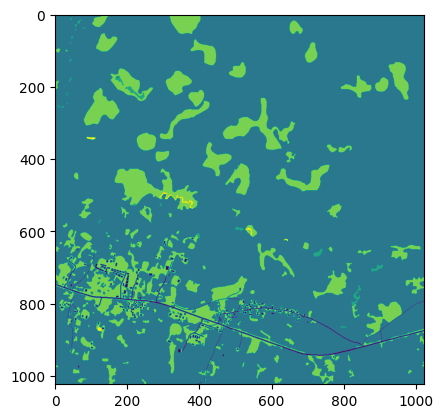

Working on  4523_4210_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


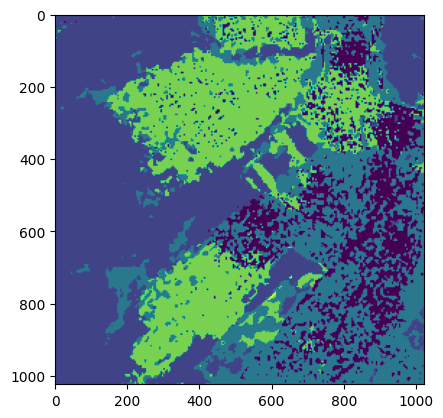

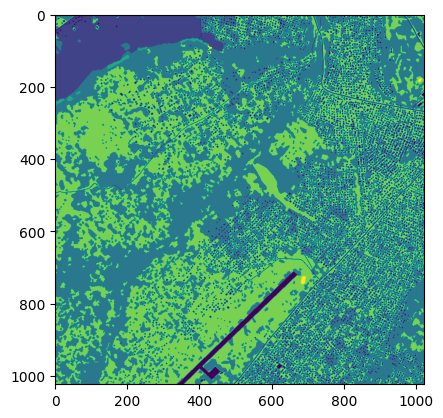

Working on  4553_3325_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


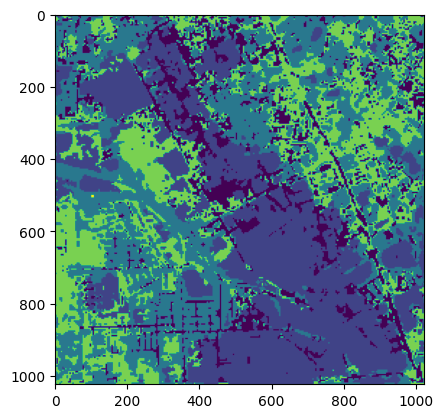

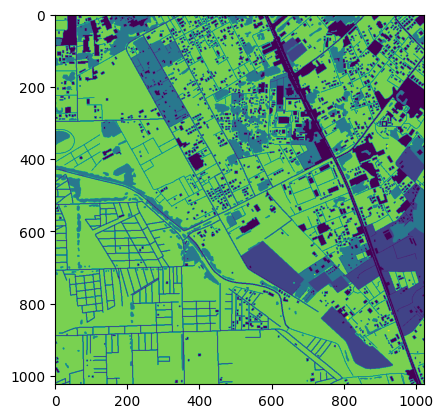

Working on  5195_3388_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


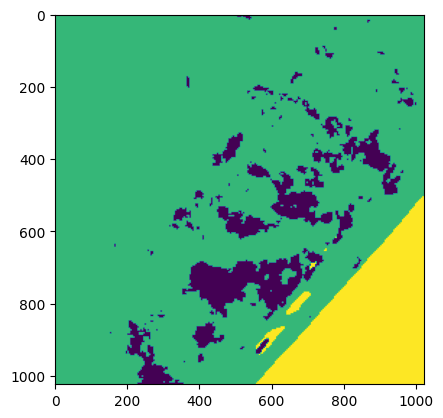

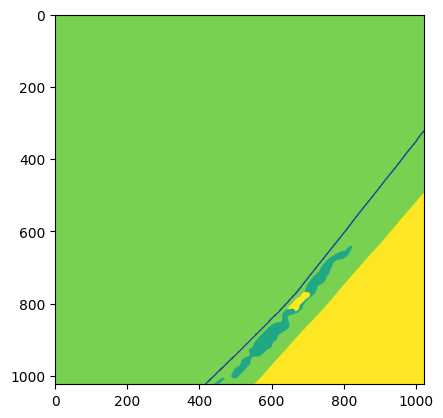

Working on  5754_3601_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


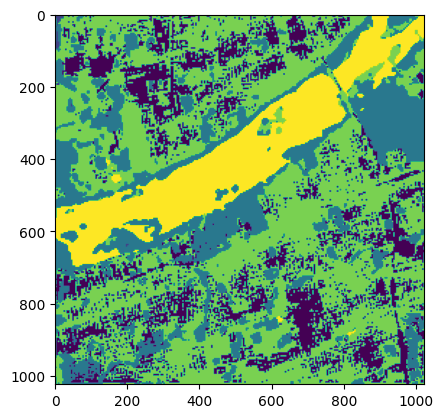

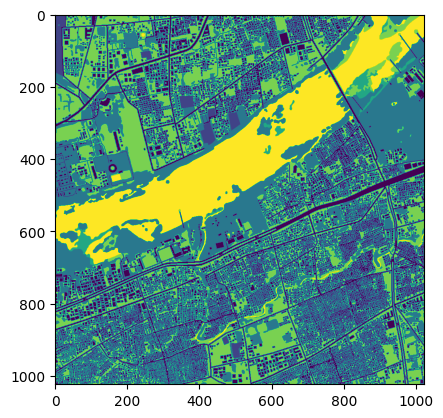

Working on  5912_3937_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


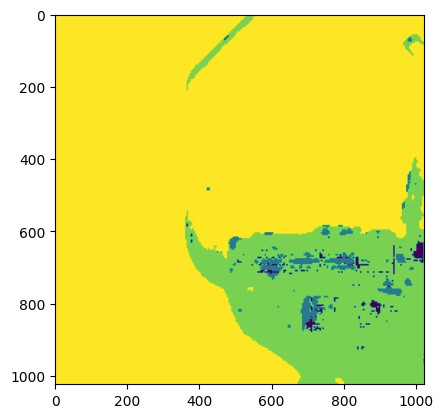

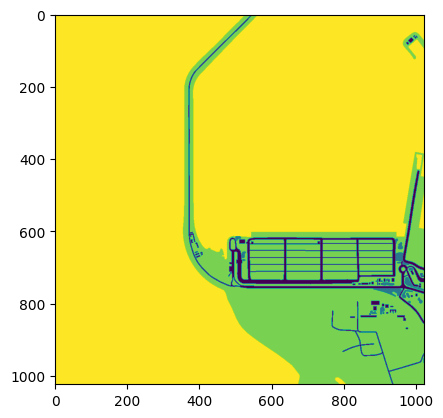

Working on  6752_3104_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


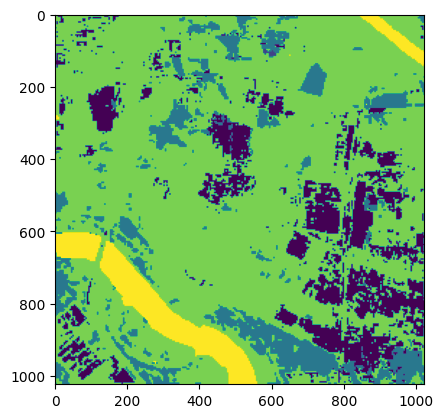

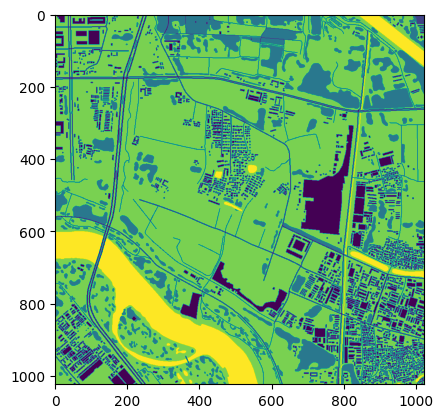

Individual subset mIOUs: [0.4001076436585019, 0.47215217764603834, 0.24489443059683197, 0.19065405031147992, 0.1410283058312144, 0.21062255976057753, 0.3188975124384918, 0.3431741221692679, 0.46302550945595866, 0.36065611167667777]
Individual subset weighted F1s: [0.8345935294714928, 0.7667716638773912, 0.6729865489271837, 0.7533766189446572, 0.3930295348780472, 0.5236115005269153, 0.7979890417660196, 0.577851173190114, 0.9130085772825388, 0.6852824649378374]
Dataset mIOU: 0.41155676230824767
Dataset weighted F1: 0.687556884653376
Dataset weighted F1 - corrected: 0.6875069357301397
Dataset macro F1: 0.525859820934827
Dataset macro F1 - corrected: 0.5258281805105782
____
=> loading checkpoint './methods/GASSL/moco_fmow/weights/moco_geo.pth.tar'
=> loaded MoCo‐pretrained weights from './methods/GASSL/moco_fmow/weights/moco_geo.pth.tar'
318 tensor(s) updated after loading weights...


Using 16bit None Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                    | Type                 | Params
-----------------------------------------------------------------
0 | scaling_transform       | Compose              | 0     
1 | encoder                 | MoCoResNet50Backbone | 23.5 M
2 | decoder                 | UPerNetDecoder       | 13.8 M
3 | segmentation_head       | SegmentationHead     | 1.8 K 
4 | loss_fn               

Training: 0it [00:00, ?it/s]

C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Epoch 8, global step 2970: 'valid_loss' was not in top 1


Validation: 0it [00:00, ?it/s]

Monitored metric valid_loss did not improve in the last 3 records. Best score: 0.834. Signaling Trainer to stop.
Epoch 9, global step 3300: 'valid_loss' was not in top 1


Run # 4
TEST set:
Working on  1286_2921_13 (# 1 / 1 )
Number of all paths: 24


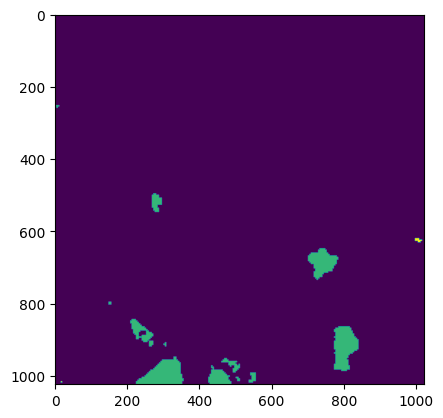

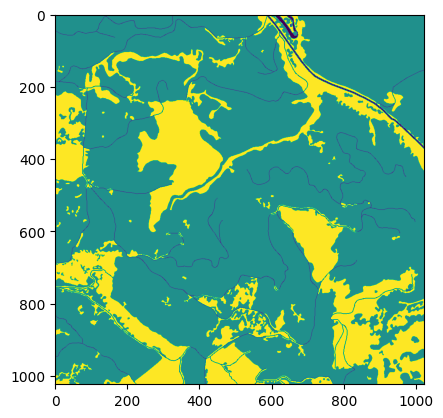

Working on  1330_3107_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


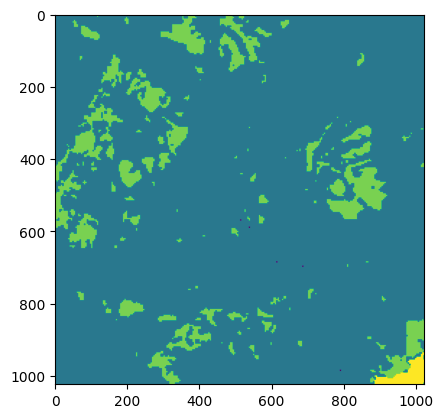

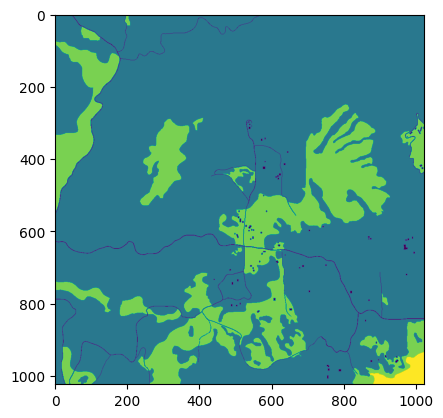

Working on  2196_3885_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


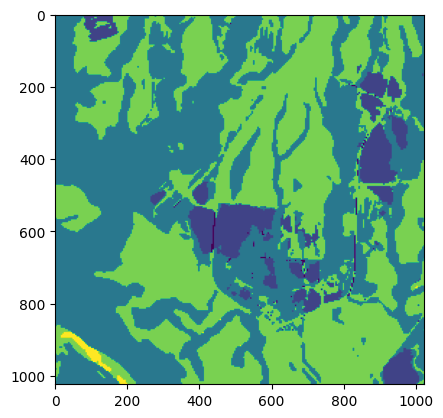

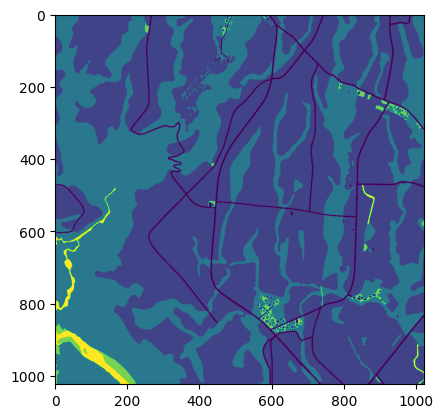

Working on  3830_3914_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


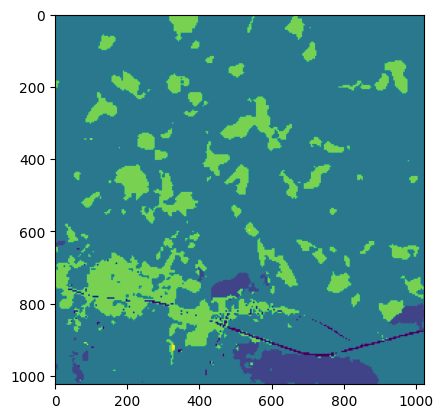

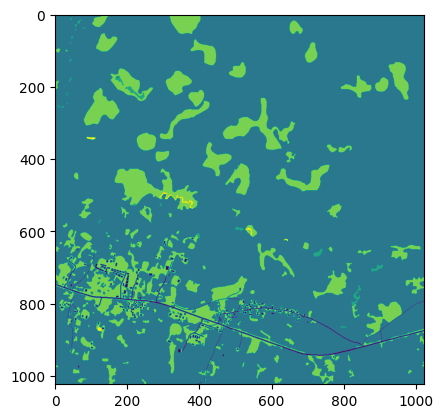

Working on  4523_4210_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


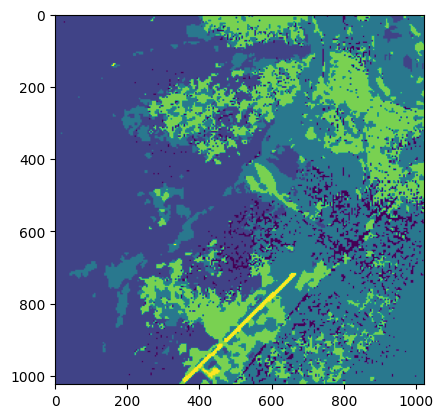

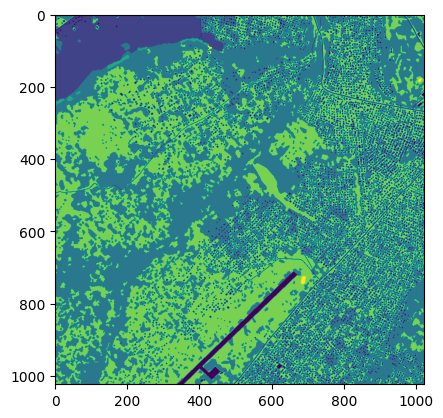

Working on  4553_3325_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


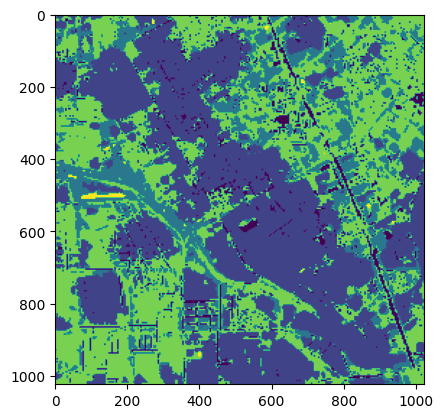

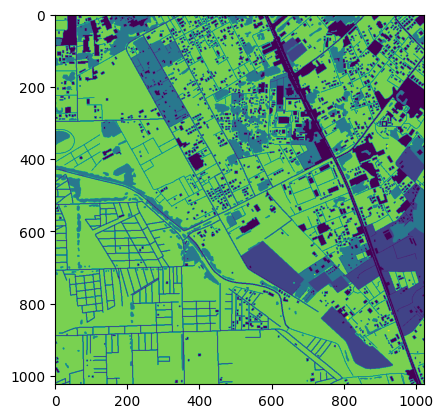

Working on  5195_3388_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


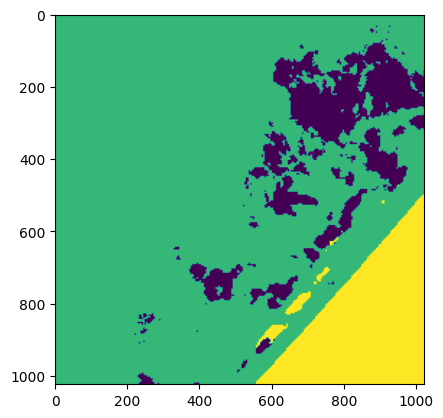

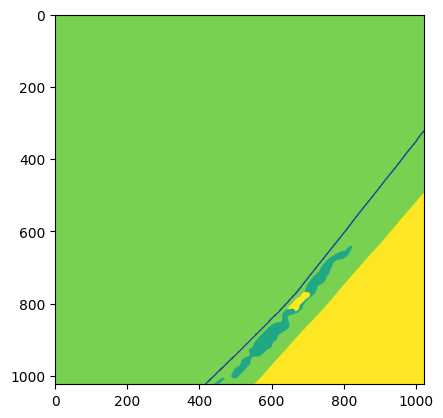

Working on  5754_3601_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


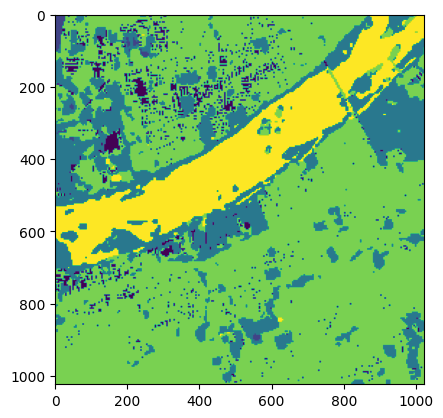

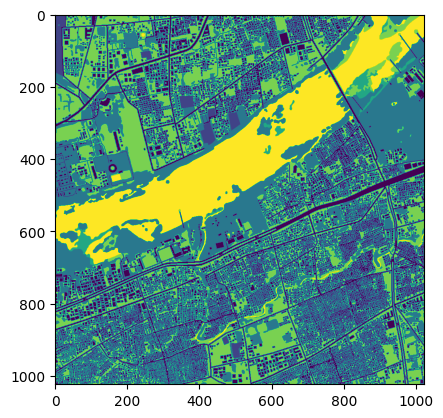

Working on  5912_3937_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


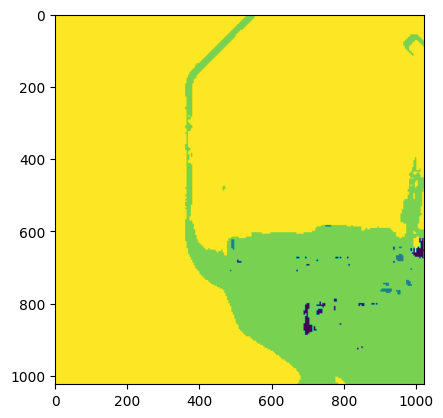

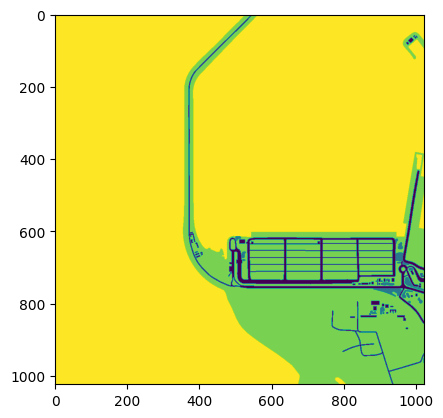

Working on  6752_3104_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


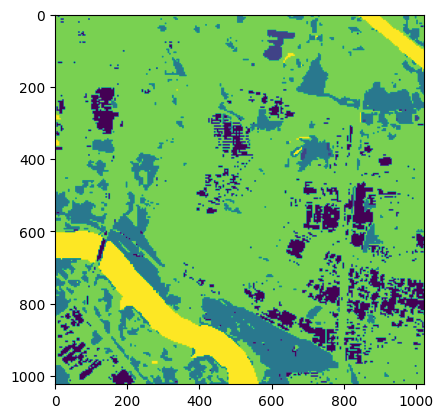

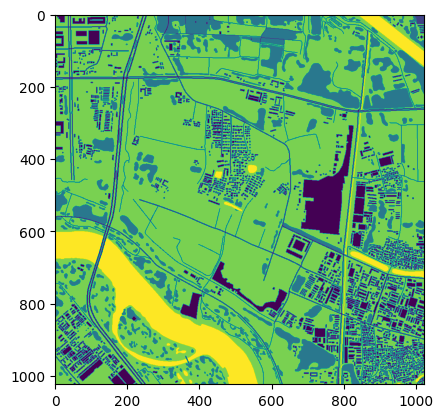

Individual subset mIOUs: [0.4796596684379635, 0.4948945158734167, 0.253859331884449, 0.29851764647389994, 0.14145957155590017, 0.25921855173718, 0.3915321023075197, 0.3472814512220694, 0.4976069245822484, 0.37037133426392743]
Individual subset weighted F1s: [0.883376862442153, 0.7552375248863609, 0.5488004430778287, 0.851890316522181, 0.40293765368882667, 0.5110382006096353, 0.8682030941345887, 0.5390914912485804, 0.9240965560920866, 0.6964118680957411]
Dataset mIOU: 0.4005285975844551
Dataset weighted F1: 0.6897358194968534
Dataset weighted F1 - corrected: 0.6897358194968534
Dataset macro F1: 0.502866206042116
Dataset macro F1 - corrected: 0.502866206042116
____
=> loading checkpoint './methods/GASSL/moco_fmow/weights/moco_geo.pth.tar'


Using 16bit None Automatic Mixed Precision (AMP)


=> loaded MoCo‐pretrained weights from './methods/GASSL/moco_fmow/weights/moco_geo.pth.tar'
318 tensor(s) updated after loading weights...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                    | Type                 | Params
-----------------------------------------------------------------
0 | scaling_transform       | Compose              | 0     
1 | encoder                 | MoCoResNet50Backbone | 23.5 M
2 | decoder                 | UPerNetDecoder       | 13.8 M
3 | segmentation_head       | SegmentationHead     | 1.8 K 
4 | loss_fn                 | SoftCrossEntropyLoss | 0     
5 | augmentatio

Training: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Epoch 6, global step 2310: 'valid_loss' was not in top 1


Validation: 0it [00:00, ?it/s]

Monitored metric valid_loss did not improve in the last 3 records. Best score: 0.839. Signaling Trainer to stop.
Epoch 7, global step 2640: 'valid_loss' was not in top 1


Run # 5
TEST set:
Working on  1286_2921_13 (# 1 / 1 )
Number of all paths: 24


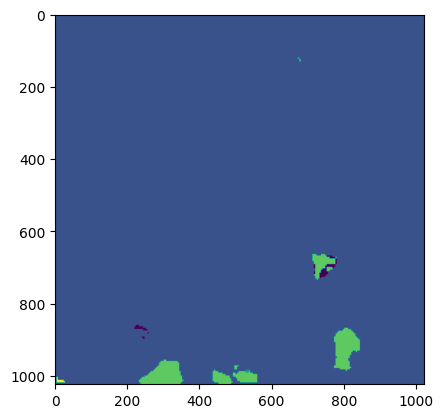

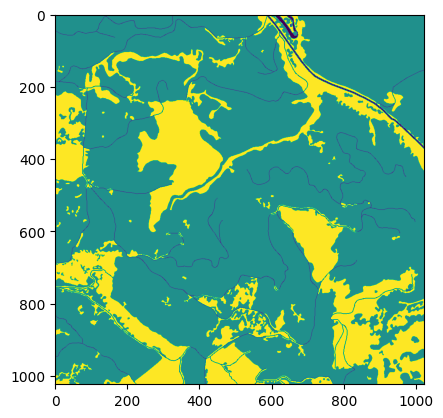

Working on  1330_3107_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


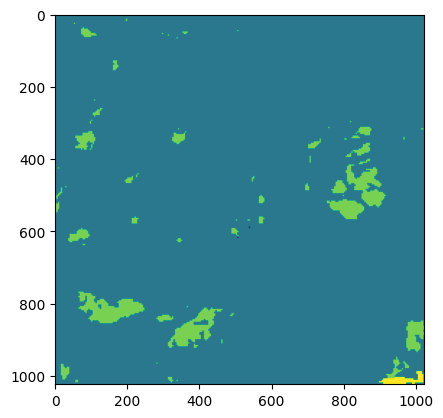

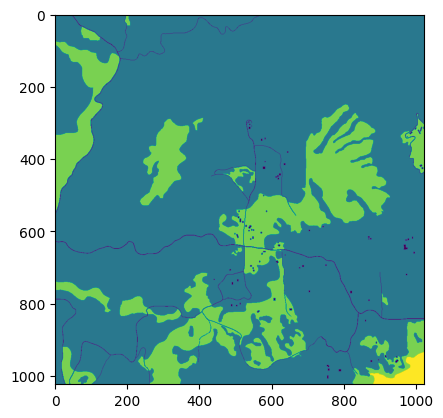

Working on  2196_3885_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


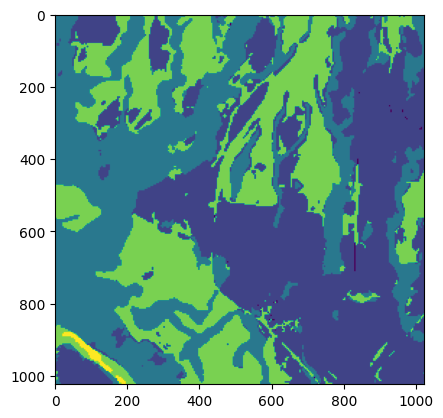

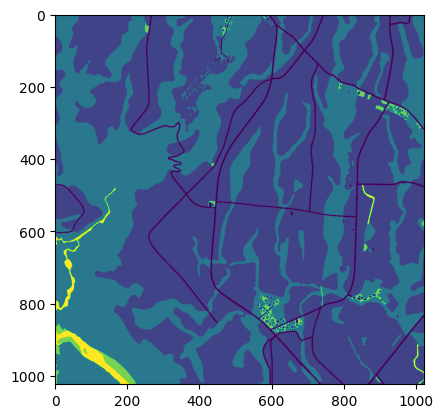

Working on  3830_3914_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


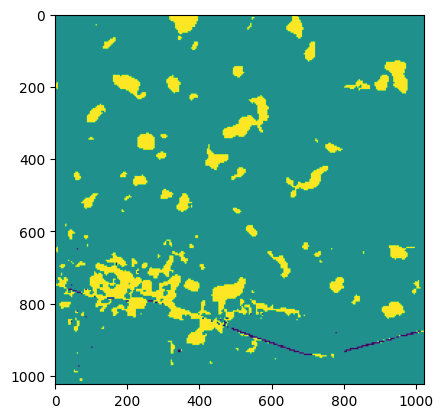

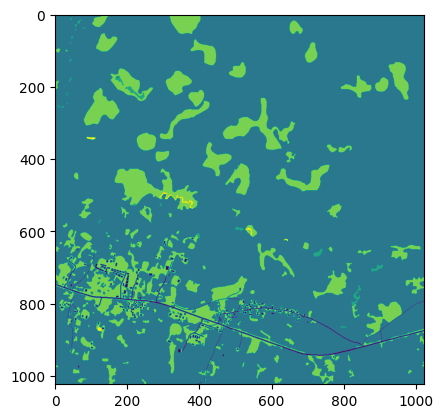

Working on  4523_4210_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


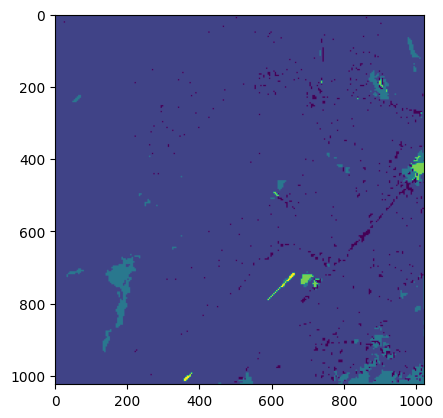

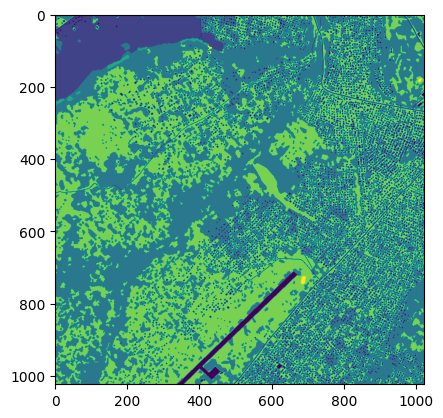

Working on  4553_3325_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


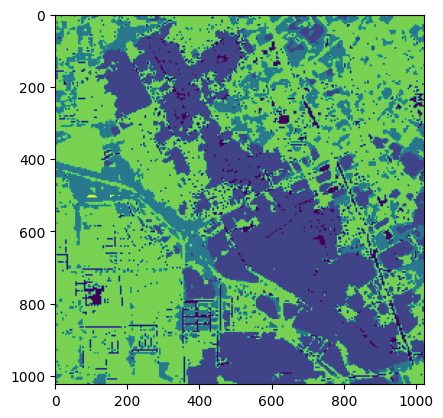

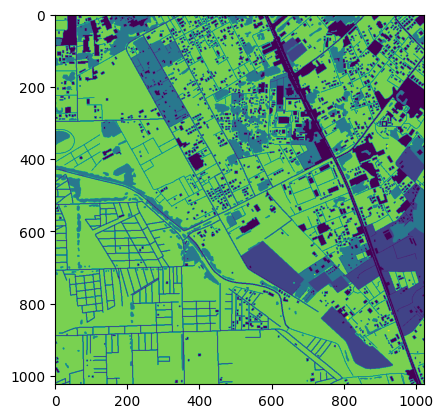

Working on  5195_3388_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


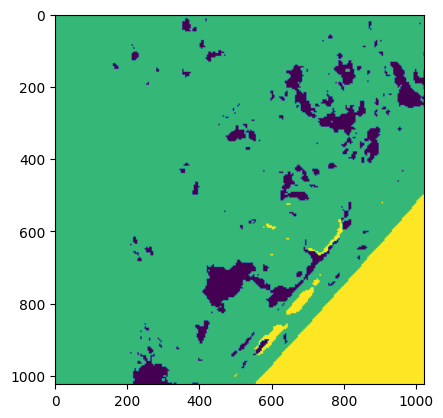

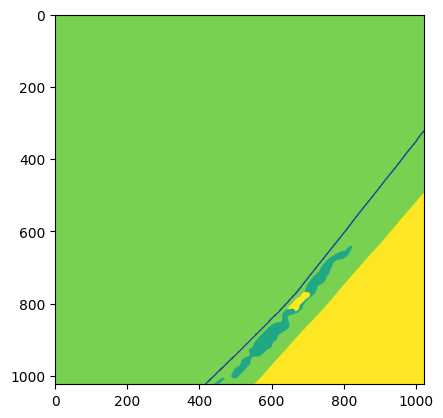

Working on  5754_3601_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


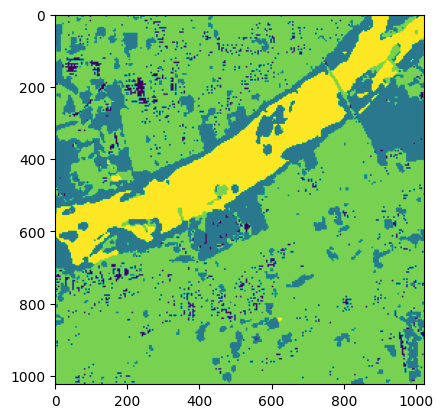

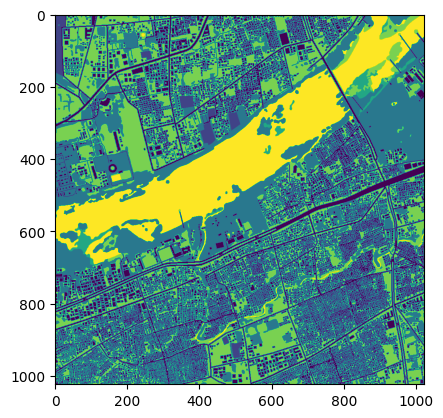

Working on  5912_3937_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


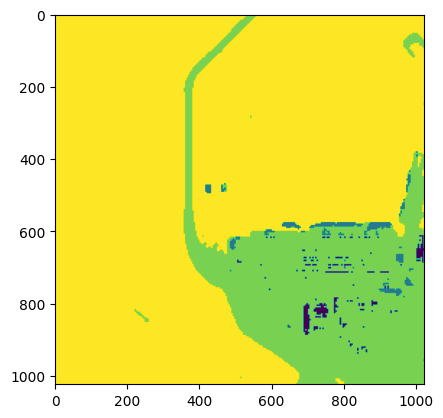

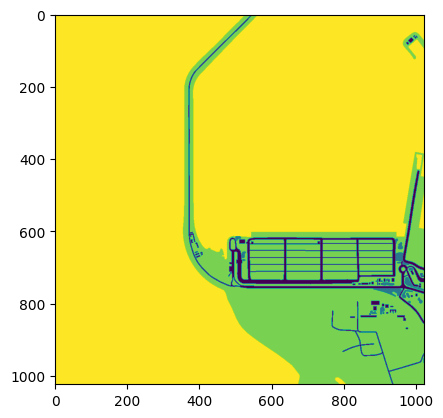

Working on  6752_3104_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


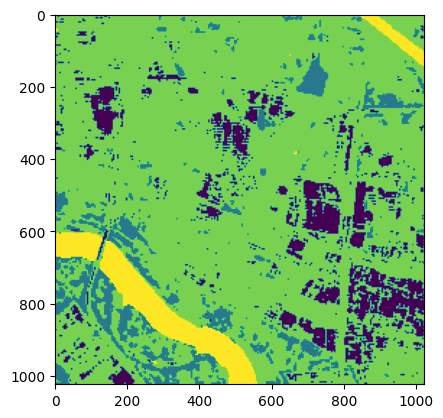

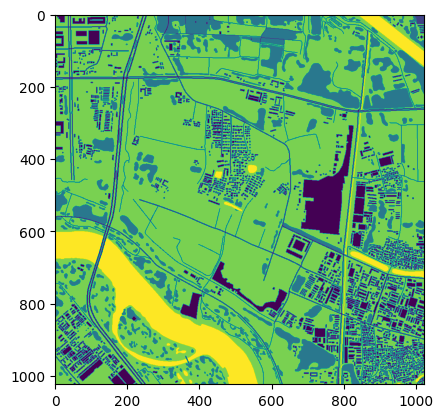

Individual subset mIOUs: [0.46113179900751344, 0.48634783869629994, 0.29958151952645456, 0.26242043997057174, 0.0728826828950555, 0.20482013986207356, 0.3595073633317273, 0.3141903701781759, 0.47402909984212815, 0.36562963781888486]
Individual subset weighted F1s: [0.8737136627839904, 0.7718845112975633, 0.7423740680463116, 0.8411495042583472, 0.22187016608305135, 0.5239627806092205, 0.7879493640180081, 0.5113888623914636, 0.9058673232588331, 0.6909882811945418]
Dataset mIOU: 0.402494473186523
Dataset weighted F1: 0.6796190459576337
Dataset weighted F1 - corrected: 0.6795996135911653
Dataset macro F1: 0.5058544964132256
Dataset macro F1 - corrected: 0.5058457024189406
____
=> loading checkpoint './methods/GASSL/moco_fmow/weights/moco_geo.pth.tar'
=> loaded MoCo‐pretrained weights from './methods/GASSL/moco_fmow/weights/moco_geo.pth.tar'
318 tensor(s) updated after loading weights...


Using 16bit None Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                    | Type                 | Params
-----------------------------------------------------------------
0 | scaling_transform       | Compose              | 0     
1 | encoder                 | MoCoResNet50Backbone | 23.5 M
2 | decoder                 | UPerNetDecoder       | 13.8 M
3 | segmentation_head       | SegmentationHead     | 1.8 K 
4 | loss_fn               

Training: 0it [00:00, ?it/s]

C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Epoch 4, global step 1650: 'valid_loss' was not in top 1


Validation: 0it [00:00, ?it/s]

Monitored metric valid_loss did not improve in the last 3 records. Best score: 0.917. Signaling Trainer to stop.
Epoch 5, global step 1980: 'valid_loss' was not in top 1


Run # 6
TEST set:
Working on  1286_2921_13 (# 1 / 1 )
Number of all paths: 24


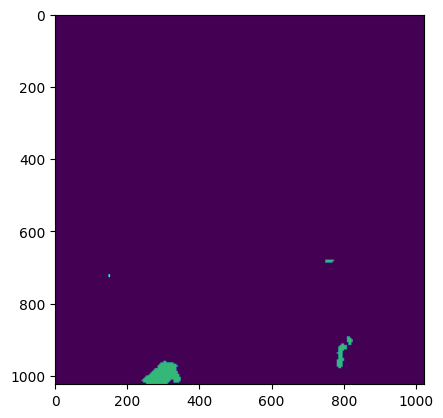

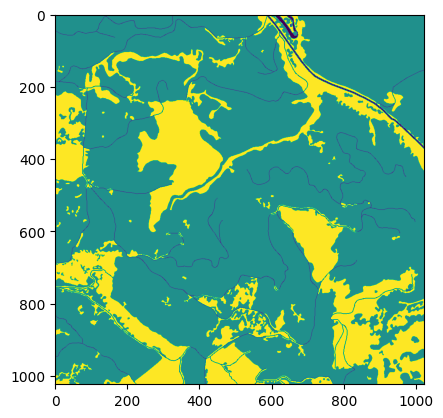

Working on  1330_3107_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


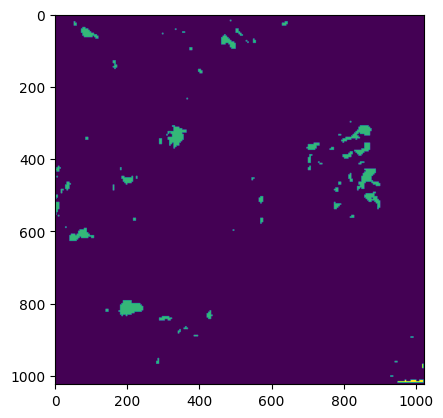

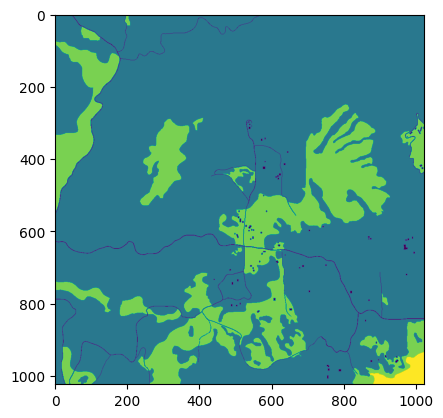

Working on  2196_3885_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


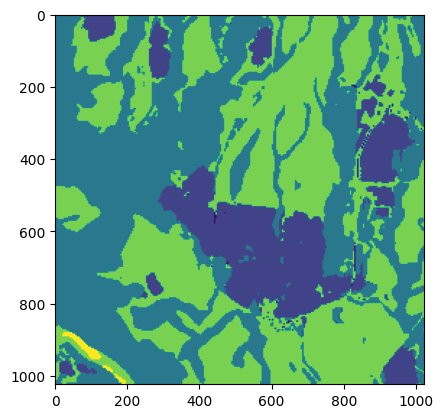

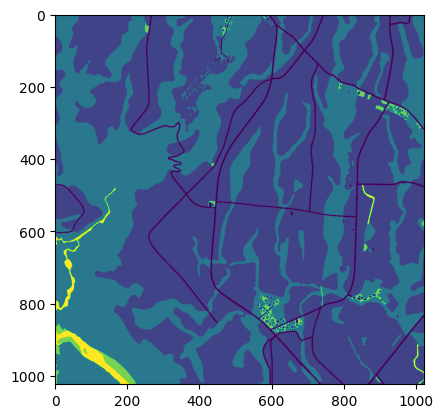

Working on  3830_3914_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


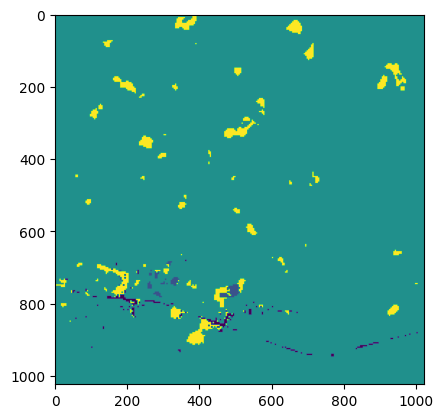

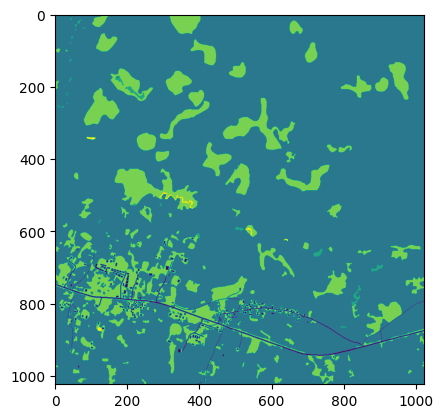

Working on  4523_4210_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


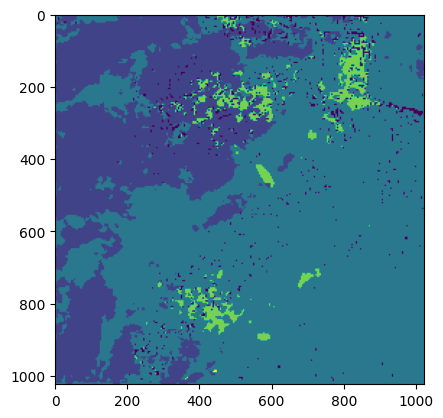

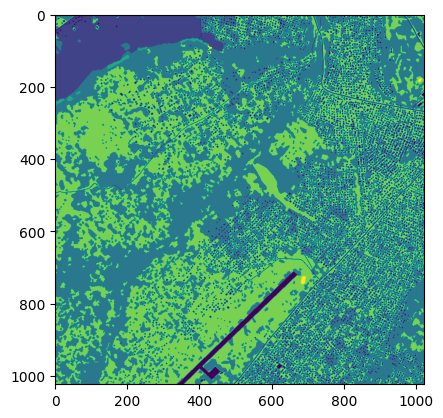

Working on  4553_3325_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


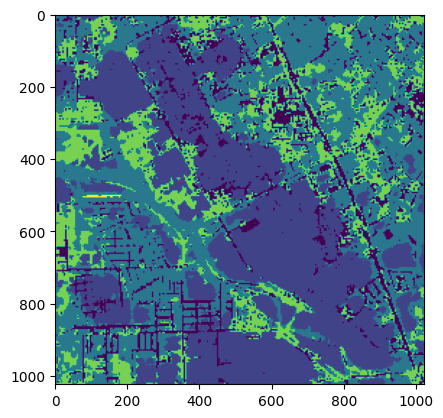

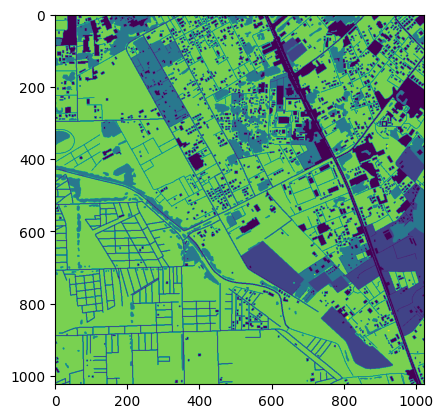

Working on  5195_3388_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


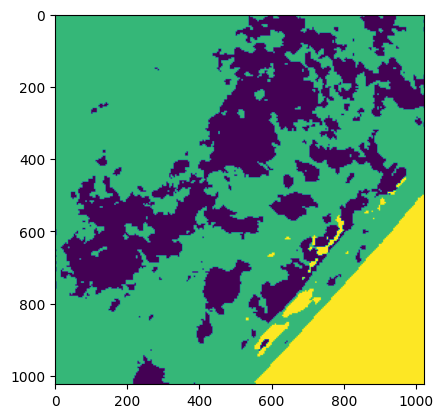

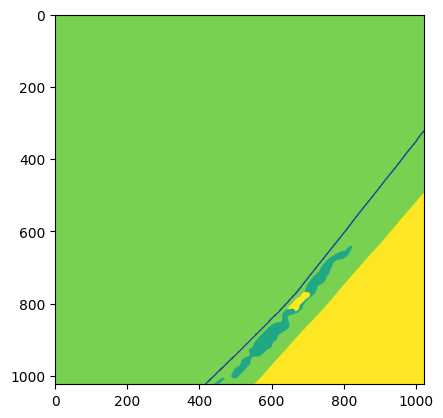

Working on  5754_3601_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


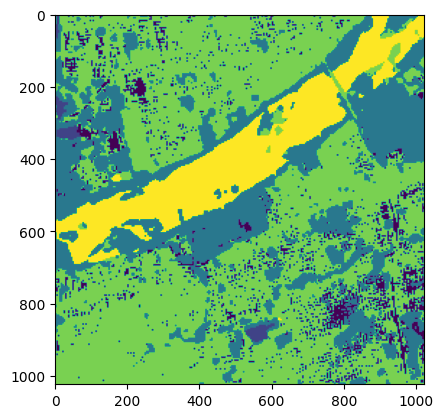

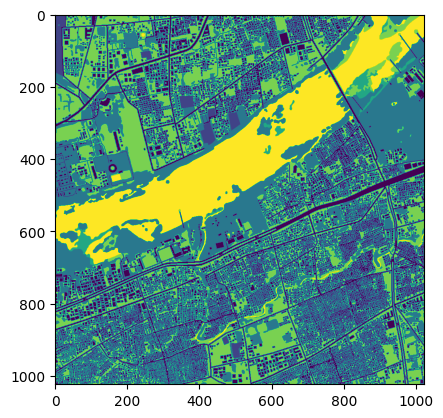

Working on  5912_3937_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


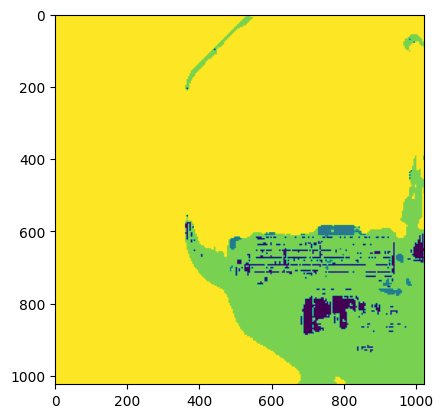

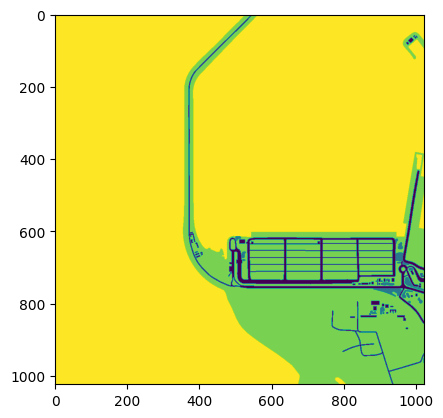

Working on  6752_3104_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


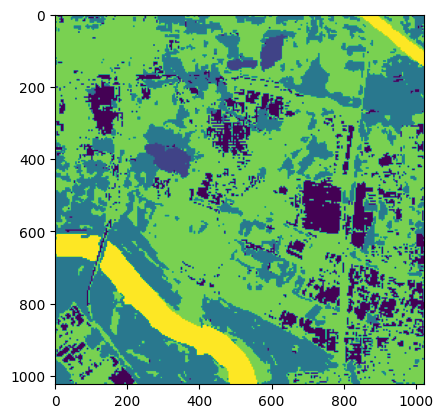

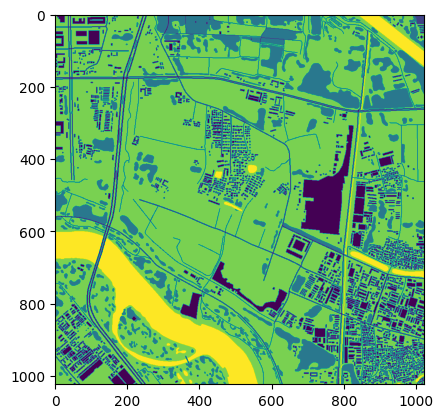

Individual subset mIOUs: [0.39768248336924156, 0.4619379404068368, 0.2795195477482622, 0.230215728426879, 0.09322243524474925, 0.2249244353040684, 0.3470224259254441, 0.3037174632312369, 0.4694137530849546, 0.3438837046634235]
Individual subset weighted F1s: [0.8350033739283002, 0.7675763334677724, 0.6800013117464644, 0.7905053346625125, 0.26978165073706933, 0.4283916776337602, 0.7616915198430791, 0.5223062009648685, 0.9150145163863798, 0.6610368931555052]
Dataset mIOU: 0.398036226355662
Dataset weighted F1: 0.6534580124866715
Dataset weighted F1 - corrected: 0.6533871984614374
Dataset macro F1: 0.5107194706695911
Dataset macro F1 - corrected: 0.5106914053434739
____
=> loading checkpoint './methods/GASSL/moco_fmow/weights/moco_geo.pth.tar'
=> loaded MoCo‐pretrained weights from './methods/GASSL/moco_fmow/weights/moco_geo.pth.tar'
318 tensor(s) updated after loading weights...


Using 16bit None Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                    | Type                 | Params
-----------------------------------------------------------------
0 | scaling_transform       | Compose              | 0     
1 | encoder                 | MoCoResNet50Backbone | 23.5 M
2 | decoder                 | UPerNetDecoder       | 13.8 M
3 | segmentation_head       | SegmentationHead     | 1.8 K 
4 | loss_fn               

Training: 0it [00:00, ?it/s]

C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Epoch 4, global step 1650: 'valid_loss' was not in top 1


Validation: 0it [00:00, ?it/s]

Monitored metric valid_loss did not improve in the last 3 records. Best score: 0.867. Signaling Trainer to stop.
Epoch 5, global step 1980: 'valid_loss' was not in top 1


Run # 7
TEST set:
Working on  1286_2921_13 (# 1 / 1 )
Number of all paths: 24


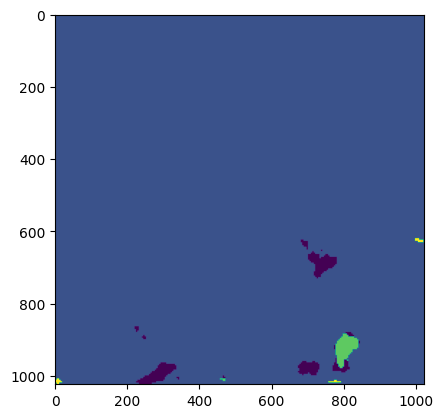

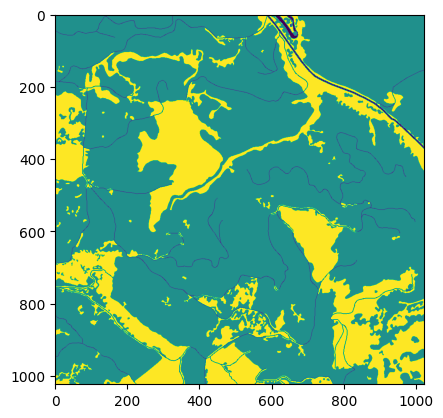

Working on  1330_3107_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


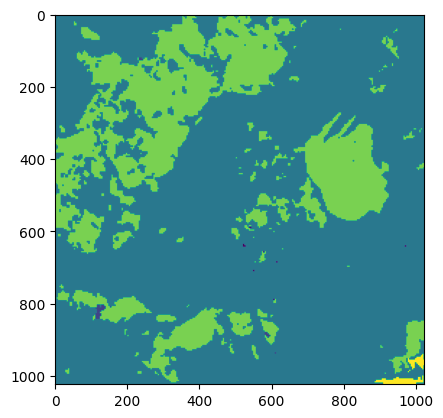

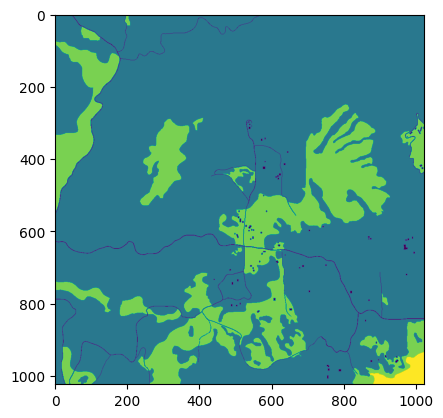

Working on  2196_3885_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


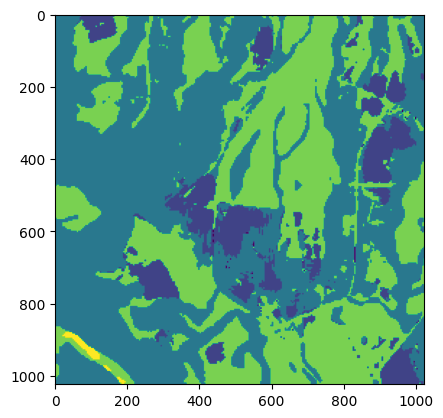

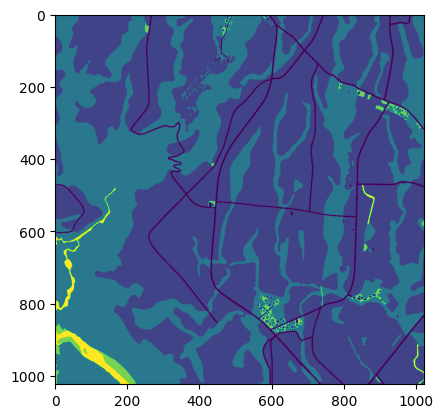

Working on  3830_3914_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


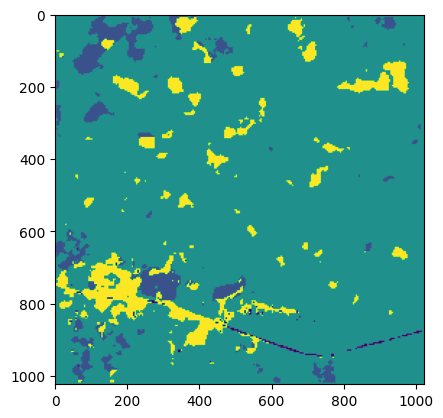

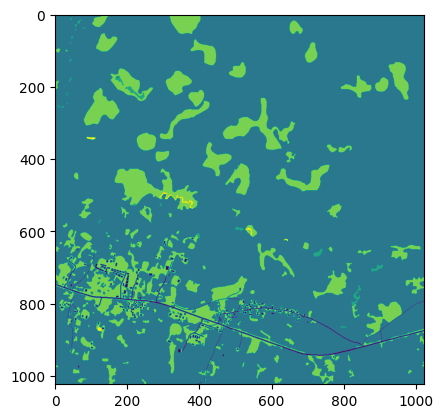

Working on  4523_4210_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


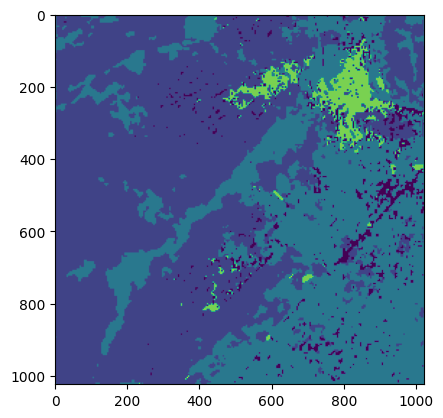

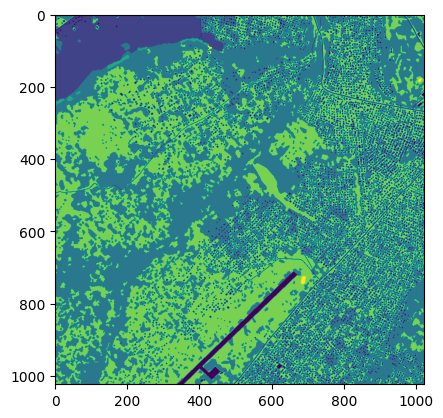

Working on  4553_3325_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


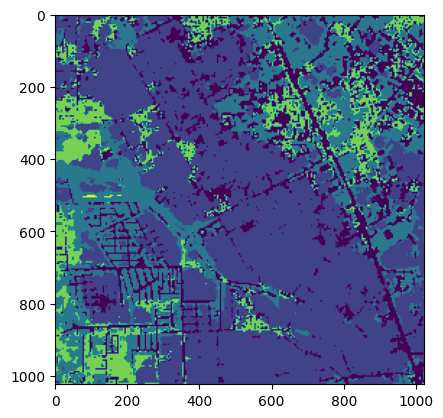

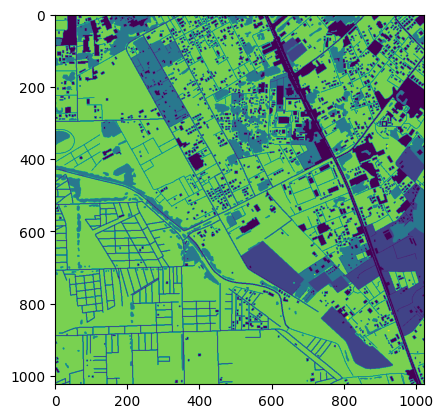

Working on  5195_3388_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


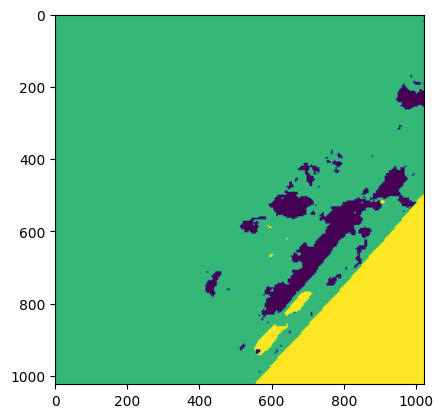

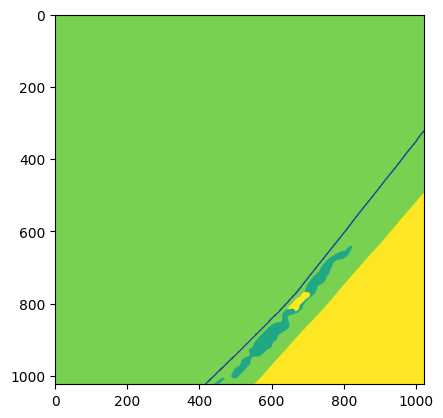

Working on  5754_3601_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


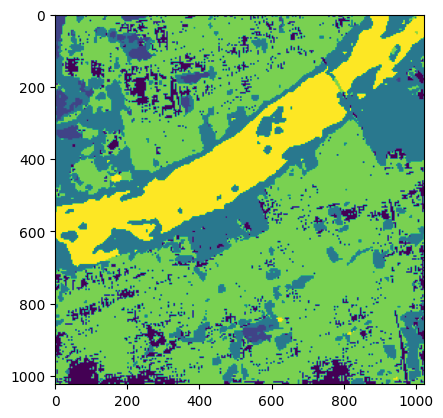

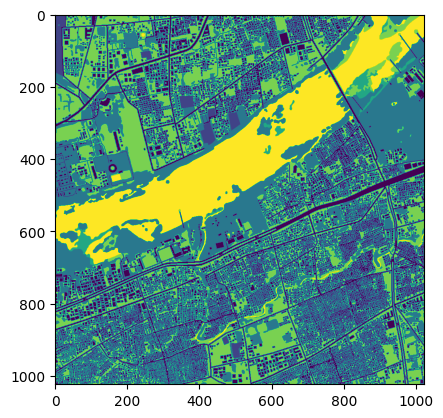

Working on  5912_3937_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


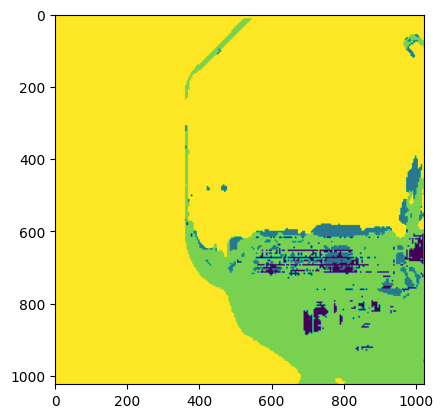

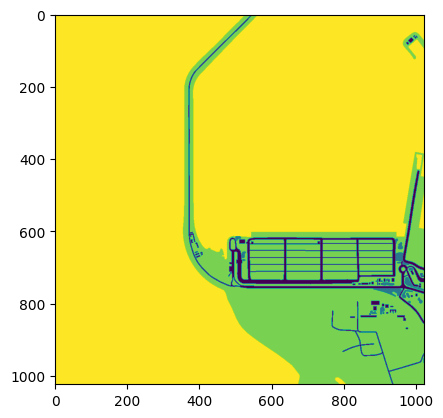

Working on  6752_3104_13 (# 1 / 1 )
Number of all paths: 24


C:\Users\Domen\anaconda3\envs\deep_learning_pytorch2.0\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


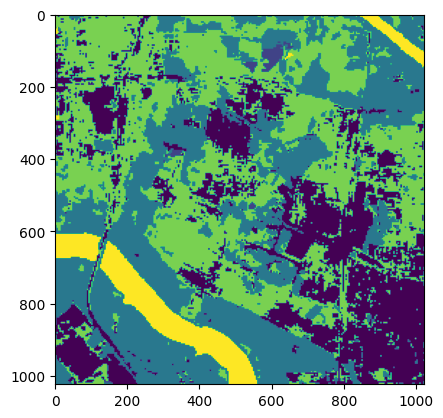

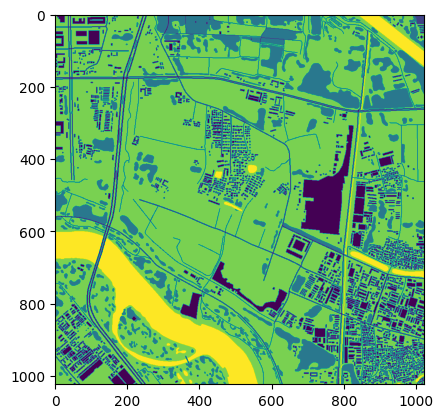

Individual subset mIOUs: [0.38531091581522453, 0.4770806296851153, 0.24255451709886838, 0.23511242947832983, 0.09299653767856779, 0.18439732952225224, 0.4082177137326143, 0.32264516653727576, 0.4555885482877605, 0.34057879732972424]
Individual subset weighted F1s: [0.82687558268836, 0.7309826377557954, 0.5956729560713444, 0.8085882213893797, 0.26592733242532074, 0.38571564691580246, 0.8883028776078423, 0.5256740953416262, 0.9030916583099612, 0.6270448546902762]
Dataset mIOU: 0.3863485078970568
Dataset weighted F1: 0.6577216559223957
Dataset weighted F1 - corrected: 0.6576829635725165
Dataset macro F1: 0.4946171251814562
Dataset macro F1 - corrected: 0.49460103384548076
____


'\nprint("VALIDATION:")\nprint("Average subset mIOU across all", n_runs, "runs:", np.mean(val_all_runs_subset_mious))\nprint("Average subset weighted F1 across all", n_runs, "runs:", np.mean(val_all_runs_subset_weighted_f1s))\nprint("Average subset macro F1 across all", n_runs, "runs:", np.mean(val_all_runs_subset_macro_f1s))\nprint("Average dataset mIOU across all", n_runs, "runs:", np.mean(val_all_runs_dataset_mious))\nprint("Average dataset weighted F1 across all", n_runs, "runs:", np.mean(val_all_runs_dataset_weighted_f1s))\nprint("Average dataset macro F1 across all", n_runs, "runs:", np.mean(val_all_runs_dataset_macro_f1s))\n\nprint("TEST:")\nprint("Average subset mIOU across all", n_runs, "runs:", np.mean(test_all_runs_subset_mious))\nprint("Average subset weighted F1 across all", n_runs, "runs:", np.mean(test_all_runs_subset_weighted_f1s))\nprint("Average subset macro F1 across all", n_runs, "runs:", np.mean(test_all_runs_subset_macro_f1s))\nprint("Average dataset mIOU across a

In [ ]:
#per subset
val_all_runs_subset_mious = []
val_all_runs_subset_weighted_f1s = []
val_all_runs_subset_macro_f1s = []
test_all_runs_subset_mious = []
test_all_runs_subset_weighted_f1s = []
test_all_runs_subset_macro_f1s = []

#per dataset
val_all_runs_dataset_mious = []
val_all_runs_dataset_weighted_f1s = []
val_all_runs_dataset_macro_f1s = []
val_all_runs_dataset_weighted_f1s_correct = []
val_all_runs_dataset_macro_f1s_correct = []
test_all_runs_dataset_mious = []
test_all_runs_dataset_weighted_f1s = []
test_all_runs_dataset_macro_f1s = []
test_all_runs_dataset_weighted_f1s_correct = []
test_all_runs_dataset_macro_f1s_correct = []

load_trained_models_if_learning_fails_between_runs = False
trained_models_to_load = []
if load_trained_models_if_learning_fails_between_runs is True:
    trained_models_to_load = [1,2,3,4,5,6,7]

for run in range(0, n_runs):
    model = MyModel(model_arch, in_channels, n_classes, train_means, train_stds, loss_function, T_MAX)

    if load_trained_models_if_learning_fails_between_runs is True and (run + 1) in trained_models_to_load:
        print("Loading model #", str(run + 1))
        checkpoint = torch.load("logs/" + model_arch + "/" + loss_function + "/run_" + str(run + 1) + "/best-checkpoint.ckpt")
        model.load_state_dict(checkpoint['state_dict'])
    else:
        early_stop_callback = EarlyStopping(monitor="valid_loss", min_delta=0.00, patience=patience, verbose=True, mode="min")
    
        checkpoint_callback = ModelCheckpoint(
            dirpath="logs/" + model_arch + "/" + loss_function + "/run_" + str(run + 1),
            monitor="valid_loss",     # Metric to monitor
            mode="min",             # Save when val_loss is minimal
            save_top_k=1,           # Only save the best model
            filename="best-checkpoint",  # Name of the checkpoint file
            verbose=True,           # Print messages when saving
        )
        
        logger = CSVLogger(save_dir="logs", name="experiment")
        
        trainer = pl.Trainer(max_epochs=n_epochs,
                         log_every_n_steps=log_every_n_steps,
                         accelerator="gpu",
                         num_sanity_val_steps=0,
                         callbacks=[early_stop_callback, checkpoint_callback],
                         logger=logger, precision=16)
    
        model.train()
        
        trainer.fit(
            model,
            train_dataloaders=train_dataloader,
            val_dataloaders=val_dataloader,
        )
    
        checkpoint = torch.load(checkpoint_callback.best_model_path)
        model.load_state_dict(checkpoint['state_dict'])

    device = torch.device("cuda:0")
    model = model.to(device)
    model.eval()

    print("Run #", str(run + 1))
    print("TEST set:")
    subset_mious, subset_weighted_f1s, subset_macro_f1s, dataset_miou, dataset_weighted_f1, dataset_macro_f1, dataset_weighted_f1_correct, dataset_macro_f1_correct = run_metrics(model, "test", test_sets, n_classes, RGB_or_RGB_plus_near_INFRARED, num_workers, test_all_runs_subset_mious, test_all_runs_subset_weighted_f1s, test_all_runs_subset_macro_f1s, show_images, relative_path_to_data=relative_path_to_data, keep_interval = "monthly", temporal=is_temporal, device = device)
    test_all_runs_dataset_mious.append(dataset_miou)
    test_all_runs_dataset_weighted_f1s.append(dataset_weighted_f1)
    test_all_runs_dataset_macro_f1s.append(dataset_macro_f1)
    test_all_runs_dataset_weighted_f1s_correct.append(dataset_weighted_f1_correct)
    test_all_runs_dataset_macro_f1s_correct.append(dataset_macro_f1_correct)
    print("Individual subset mIOUs:", subset_mious)
    print("Individual subset weighted F1s:", subset_weighted_f1s)
    print("Dataset mIOU:", dataset_miou)
    print("Dataset weighted F1:", dataset_weighted_f1)
    print("Dataset weighted F1 - corrected:", dataset_weighted_f1_correct)
    print("Dataset macro F1:", dataset_macro_f1)
    print("Dataset macro F1 - corrected:", dataset_macro_f1_correct)
    print("____")

    #CLEAR MODEL
    # Move model to CPU
    model = model.cpu()
    # Delete the model reference
    del model
    # Clear the PyTorch GPU cache
    torch.cuda.empty_cache()
    # Force Python garbage collection
    gc.collect()

with open(model_arch + "_" + loss_function + ".txt", "a") as f:
    f.write("\nTEST:\n")
    f.write("Average subset mIOU across all " + str(n_runs) + " runs: " + str(np.mean(test_all_runs_subset_mious)) + "\n")
    f.write("Average subset weighted F1 across all " + str(n_runs) + " runs: " + str(np.mean(test_all_runs_subset_weighted_f1s)) + "\n")
    f.write("Average subset macro F1 across all " + str(n_runs) + " runs: " + str(np.mean(test_all_runs_subset_macro_f1s)) + "\n")
    f.write("Average dataset mIOU across all " + str(n_runs) + " runs: " + str(np.mean(test_all_runs_dataset_mious)) + "\n")
    f.write("Average dataset weighted F1 (masked) across all " + str(n_runs) + " runs: " + str(np.mean(test_all_runs_dataset_weighted_f1s)) + "\n")
    f.write("Average dataset weighted F1 (as filtered labels) across all " + str(n_runs) + " runs: " + str(np.mean(test_all_runs_dataset_weighted_f1s_correct)) + "\n")
    f.write("Average dataset macro F1 (masked) across all " + str(n_runs) + " runs: " + str(np.mean(test_all_runs_dataset_macro_f1s)) + "\n")
    f.write("Average dataset macro F1 (as filtered labels) across all " + str(n_runs) + " runs: " + str(np.mean(test_all_runs_dataset_macro_f1s_correct)) + "\n")
    f.write("Individual mIOUs: [" + ", ".join(str(miou) for miou in test_all_runs_dataset_mious) + "]\n")
    f.write("Individual macro F1s - masked: [" + ", ".join(str(mF1) for mF1 in test_all_runs_dataset_macro_f1s) + "]\n")
    f.write("Individual macro F1s - as filtered labels: [" + ", ".join(str(mF1) for mF1 in test_all_runs_dataset_macro_f1s_correct) + "]\n")
    f.write("Individual weighted F1s - masked: [" + ", ".join(str(mF1) for mF1 in test_all_runs_dataset_weighted_f1s) + "]\n")
    f.write("Individual weighted F1s - as filtered labels: [" + ", ".join(str(mF1) for mF1 in test_all_runs_dataset_weighted_f1s_correct) + "]")